# SmartCattle Net: A Multimodal Predictive System for Climate-Aware Cattle Farming

---
## Data set

>MMCow is a publicly available precision livestock dataset hosted on Kaggle, containing detailed per-cow, per-milking session records collected from dairy farms. It includes structured tabular data such as milk yield, milk flow rate, milking duration, days in milk (DIM), parity, somatic cell count (SCC), fat percentage, protein percentage, and environmental readings including temperature and humidity — from which the Temperature-Humidity Index (THI) is derived.

>The dataset captures multiple cows across extended lactation periods, making it well-suited for both regression and time-series tasks. Its multivariate structure — combining physiological, production, and climate signals — makes it the ideal foundation for SmartCattle Net's 12-stage chained prediction pipeline.

>For this project, the dataset was used exclusively on Kaggle for model training. Only the trained model files and prediction outputs were exported locally, keeping the workflow lightweight and reproducible without requiring full dataset downloads.

---
## about 
>SmartCattle Net is a multimodal predictive system designed to bring climate-aware intelligence to modern cattle farming. Built on the MMCow dataset, it chains 12 specialized machine learning models in sequence — where the output of each prediction enriches the input of the next — creating a progressively smarter pipeline from raw sensor data to actionable farm decisions.

>The system predicts daily milk yield, detects drop risks, forecasts next-milking output, and computes novel metrics like the Milk Stability Index (MSI) and a Climate-Gated Productivity Score that dynamically adjusts to heat stress conditions using the Temperature-Humidity Index (THI). Beyond milk analytics, it scores each cow's health, flags early anomalies, predicts physiological stress, and ranks which animals need immediate attention — giving farmers a single, unified view of their entire herd.

>What sets SmartCattle Net apart is its CCP-Chain architecture — a novel sequential prediction framework where climate context flows through every stage, ensuring that later models always benefit from the collective intelligence of earlier ones. The system is multimodal by design, supporting CSV records, camera-based body condition scoring, video gait analysis, and live weather feeds.

>The result is a farmer-facing dashboard and AI chat assistant that transforms complex livestock data into simple, prioritized decisions — helping farms improve productivity, reduce health losses, and adapt to a changing climate.

---
## Objectives
> **1.** To develop a multimodal system for accurate prediction of milk production patterns in dairy cows.\
> **2.** To derive key indicators such as milk stability, trends, and productivity using behavioral and environmental data.\
> **3.** To predict cattle stress and detect health risk conditions using integrated machine learning techniques.\
> **4.** To design an AI-based decision support system for identifying underperforming cattle and prioritizing intervention.\

In [1]:
# ── Core libraries ──────────────────────────────────────────────

import numpy as np          # Numerical computations, arrays, mathematical operations
import pandas as pd         # Data handling, tables, preprocessing

import matplotlib.pyplot as plt   # Data visualization and plotting graphs
import matplotlib.gridspec as gridspec  # Advanced subplot layouts

import seaborn as sns       # Statistical and attractive visualizations

import warnings
warnings.filterwarnings('ignore')  
# Hides unnecessary warning messages for cleaner output


# ── ML libraries ─────────────────────────────────────────────────

from sklearn.preprocessing import RobustScaler, MinMaxScaler, PolynomialFeatures

# RobustScaler → handles outliers while scaling data
# MinMaxScaler → converts values into range (0 to 1)
# PolynomialFeatures → creates interaction/polynomial features

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# train_test_split → splits dataset into train/test
# cross_val_score → evaluates model using cross validation
# StratifiedKFold → balanced splitting for classification tasks

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, roc_auc_score, confusion_matrix
)

# mean_squared_error → regression accuracy
# mean_absolute_error → average prediction error
# r2_score → goodness of fit
# classification_report → precision, recall, F1-score
# roc_auc_score → classification performance
# confusion_matrix → actual vs predicted classes

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    StackingRegressor
)

# RandomForestRegressor → ensemble regression model
# GradientBoostingClassifier → boosting classifier
# GradientBoostingRegressor → boosting regression model
# StackingRegressor → combines multiple models together

from sklearn.linear_model import Ridge, LogisticRegression

# Ridge → regularized linear regression
# LogisticRegression → classification algorithm

from sklearn.inspection import permutation_importance
# Finds important features affecting predictions

from sklearn.pipeline import Pipeline
# Automates preprocessing + modeling workflow

from sklearn.impute import KNNImputer
# Fills missing values using nearest neighbors

from sklearn.decomposition import PCA
# Reduces dimensionality/features


import xgboost as xgb
# Powerful boosting algorithm for high accuracy

import lightgbm as lgb
# Fast gradient boosting framework

from imblearn.over_sampling import SMOTE
# Balances imbalanced datasets by generating synthetic samples


# ── Time-series & forecasting ────────────────────────────────────

from statsmodels.tsa.arima.model import ARIMA
# ARIMA model for time-series forecasting

from statsmodels.tsa.stattools import adfuller
# Augmented Dickey-Fuller test for stationarity check


# ── Deep learning (LSTM) ─────────────────────────────────────────

import tensorflow as tf
# Main deep learning framework

from tensorflow.keras.models import Sequential
# Sequential neural network architecture

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

# LSTM → learns sequential/time-series patterns
# Dense → fully connected layer
# Dropout → prevents overfitting
# BatchNormalization → stabilizes training

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# EarlyStopping → stops training when no improvement
# ReduceLROnPlateau → lowers learning rate automatically

from tensorflow.keras.optimizers import Adam
# Adam optimizer for efficient training


# ── Anomaly detection ────────────────────────────────────────────

from sklearn.ensemble import IsolationForest
# Detects abnormal or unusual data points


# ── Explainability ───────────────────────────────────────────────

try:
    import shap
    SHAP_AVAILABLE = True
    
    # SHAP explains why model predictions happen

except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not available — install with: pip install shap')


# ── Model persistence ────────────────────────────────────────────

import joblib
# Saves trained ML models

import json
# Handles JSON data storage

import os
# File and directory operations


# ── Prophet (optional, graceful fallback) ───────────────────────

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    
    # Prophet → Facebook forecasting model

except ImportError:
    PROPHET_AVAILABLE = False
    print('Prophet not available — Stage 6 will use ARIMA only')


# ── Global settings ──────────────────────────────────────────────

RANDOM_STATE = 42

# Fixed seed for reproducibility

np.random.seed(RANDOM_STATE)
# Makes NumPy results reproducible

tf.random.set_seed(RANDOM_STATE)
# Makes TensorFlow results reproducible

plt.style.use('seaborn-v0_8-whitegrid')
# Better graph style

COLORS = [
    '#378ADD',
    '#1D9E75',
    '#D85A30',
    '#7F77DD',
    '#E24B4A',
    '#BA7517'
]

# Custom color palette for visualizations


OUTPUT_DIR = '/kaggle/working/smartcattle_models/'

# Directory where trained models will be stored

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Creates folder if it doesn't exist


print('✓ All libraries loaded')

# Confirmation message

print(f'✓ TensorFlow version: {tf.__version__}')

# Shows TensorFlow version

print(f'✓ Output directory: {OUTPUT_DIR}')

# Displays model save location

2026-07-19 06:59:56.004707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784444396.202088      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784444396.259155      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784444396.753837      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784444396.753882      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784444396.753885      57 computation_placer.cc:177] computation placer alr

✓ All libraries loaded
✓ TensorFlow version: 2.19.0
✓ Output directory: /kaggle/working/smartcattle_models/


In [2]:
import tensorflow as tf

# Import TensorFlow for deep learning

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Checks how many GPUs are available

print(tf.config.list_physical_devices('GPU'))

# Displays detected GPU devices

Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os

# Import os module for file and directory operations

for root, dirs, files in os.walk('/kaggle/input'):

    # Traverses through all folders inside /kaggle/input

    for file in files[:20]:

        # Selects first 20 files from each folder

        print(os.path.join(root, file))

        # Prints complete file path

/kaggle/input/datasets/hienvuvg/mmcows/download link.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690325126_17-45-26.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690321946_16-52-26.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690327151_18-19-11.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690334081_20-14-41.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690285871_06-51-11.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690332281_19-44-41.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690279991_05-13-11.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725/cam_3/1690333136_19-58-56.txt
/kaggle/input/datasets/hienvuvg/mmcows/visual_data/visu

In [4]:
import os

# Import os module for directory handling

for root, dirs, files in os.walk('/kaggle/input'):

    # Traverses all folders inside /kaggle/input

    print("FOLDER:", root)

    # Prints folder name/path

    for file in files[:10]:

        # Selects first 10 files from folder

        print("   ", file)

        # Prints file names

    print("-" * 50)

    # Prints separator line for readability

FOLDER: /kaggle/input
--------------------------------------------------
FOLDER: /kaggle/input/datasets
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows
    download link.txt
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows/visual_data
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying
--------------------------------------------------
FOLDER: /kaggle/input/datasets/hienvuvg/mmcows/visual_data/visual_data/labels/lying/0725
-------------------------------------------------

In [5]:
import pandas as pd

# Import pandas for data handling

df_raw = pd.read_csv(
    '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/milk/C04.csv'
)

# Reads the C04.csv dataset into a DataFrame

print(df_raw.head())

# Displays first 5 rows of dataset

      timestamp  milk_weight_kg    DIM
0  1.689959e+09          37.104  583.0
1  1.690045e+09          34.972  584.0
2  1.690132e+09          37.557  585.0
3  1.690218e+09          38.102  586.0
4  1.690304e+09          37.693  587.0


In [6]:
print(df_raw.columns)

# Displays all column names in the dataset

print(df_raw.columns.tolist())

# Converts column names into list format

Index(['timestamp', 'milk_weight_kg', 'DIM'], dtype='object')
['timestamp', 'milk_weight_kg', 'DIM']


In [7]:
# ── EDA: Overview ────────────────────────────────────────────────

print('=== DATASET INFO ===')

# Prints dataset structure, column types, and non-null values

print(df_raw.info())


print('\n=== MISSING VALUES ===')

# Checks missing values in each column

missing = df_raw.isnull().sum()

# Counts total null values column-wise

print(missing[missing > 0])

# Displays only columns with missing values


print('\n=== DESCRIPTIVE STATISTICS ===')

# Shows statistical summary of numerical columns

df_raw.describe()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       15 non-null     float64
 1   milk_weight_kg  15 non-null     float64
 2   DIM             15 non-null     float64
dtypes: float64(3)
memory usage: 492.0 bytes
None

=== MISSING VALUES ===
Series([], dtype: int64)

=== DESCRIPTIVE STATISTICS ===


,timestamp,milk_weight_kg,DIM
count,1.500000e+01,15.000000,15.000000
mean,1.690564e+09,38.035267,590.000000
std,3.863925e+05,1.979849,4.472136
min,1.689959e+09,34.972000,583.000000
25%,1.690261e+09,36.809000,586.500000
50%,1.690564e+09,37.693000,590.000000
75%,1.690866e+09,39.145000,593.500000
max,1.691168e+09,42.320000,597.000000


In [8]:
import numpy as np

# Used for numerical computations and arrays

import pandas as pd

# Used for data handling and preprocessing

import matplotlib.pyplot as plt

# Used for plotting graphs and visualizations

import seaborn as sns

# Used for advanced statistical visualizations


plt.style.use('seaborn-v0_8-whitegrid')

# Applies clean whitegrid style to plots


COLORS = [
    '#378ADD',
    '#1D9E75',
    '#D85A30',
    '#7F77DD',
    '#E24B4A',
    '#BA7517'
]

# Custom color palette for graphs

In [9]:
print(df_raw.columns.tolist())

# Displays all dataset column names in list format

['timestamp', 'milk_weight_kg', 'DIM']


      timestamp  milk_weight_kg    DIM
0  1.689959e+09          37.104  583.0
1  1.690045e+09          34.972  584.0
2  1.690132e+09          37.557  585.0
3  1.690218e+09          38.102  586.0
4  1.690304e+09          37.693  587.0
      timestamp  temperature_F  humidity_per    THI
0  1.689961e+09          25.80         50.62  73.10
1  1.689961e+09          25.47         50.71  72.69
2  1.689961e+09          25.19         51.37  72.38
3  1.689961e+09          24.95         51.97  72.13
4  1.689961e+09          24.78         51.74  71.88


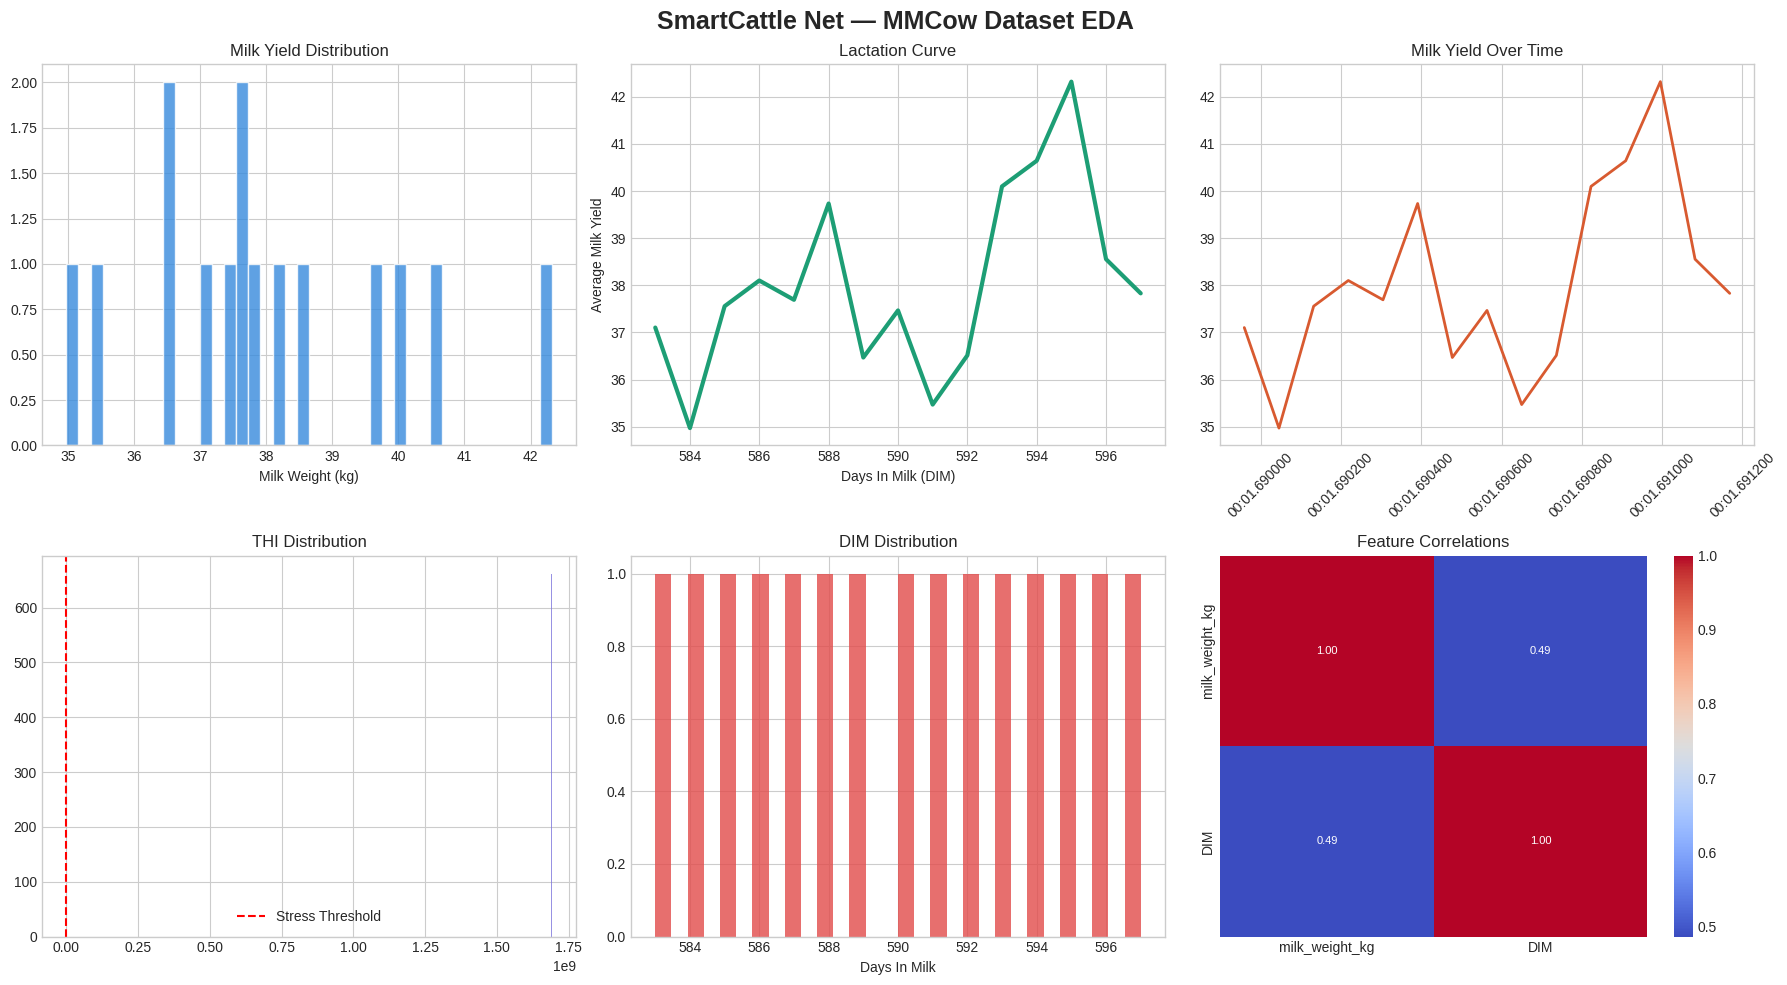

✓ EDA graphs generated successfully


In [10]:
import pandas as pd
# Used for loading and handling datasets

import numpy as np
# Used for numerical operations

import matplotlib.pyplot as plt
# Used for plotting graphs

import seaborn as sns
# Used for advanced visualizations


plt.style.use('seaborn-v0_8-whitegrid')
# Applies clean graph style

COLORS = ['#378ADD', '#1D9E75', '#D85A30',
          '#7F77DD', '#E24B4A', '#BA7517']
# Custom colors for plots


# =========================================================
# LOAD MILK DATA
# =========================================================

milk_path = '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/milk/C04.csv'
# Path of milk dataset

df_milk = pd.read_csv(milk_path)
# Loads milk dataset into DataFrame

print(df_milk.head())
# Displays first 5 rows


# =========================================================
# LOAD THI DATA
# =========================================================

thi_path = '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/thi/average.csv'
# Path of THI dataset

df_thi = pd.read_csv(thi_path)
# Loads THI dataset

print(df_thi.head())
# Displays first 5 rows


# =========================================================
# COLUMN FIXES
# =========================================================

df_milk.columns = df_milk.columns.str.strip()
df_thi.columns = df_thi.columns.str.strip()
# Removes unwanted spaces from column names

df_milk['timestamp'] = pd.to_datetime(df_milk['timestamp'])
# Converts timestamp column into datetime format


# =========================================================
# EDA VISUALIZATION
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Creates 2x3 subplot layout

fig.suptitle(
    'SmartCattle Net — MMCow Dataset EDA',
    fontsize=18,
    fontweight='bold'
)
# Main title for dashboard


# =========================================================
# PLOT 1 — MILK DISTRIBUTION
# =========================================================

axes[0,0].hist(
    df_milk['milk_weight_kg'].dropna(),
    bins=40,
    color=COLORS[0],
    alpha=0.8,
    edgecolor='white'
)
# Histogram showing milk yield distribution

axes[0,0].set_title('Milk Yield Distribution')
axes[0,0].set_xlabel('Milk Weight (kg)')


# =========================================================
# PLOT 2 — DIM VS MILK
# =========================================================

dim_yield = df_milk.groupby('DIM')['milk_weight_kg'].mean()
# Calculates average milk yield for each DIM

axes[0,1].plot(
    dim_yield.index,
    dim_yield.values,
    color=COLORS[1],
    linewidth=3
)
# Lactation curve plot

axes[0,1].set_title('Lactation Curve')
axes[0,1].set_xlabel('Days In Milk (DIM)')
axes[0,1].set_ylabel('Average Milk Yield')


# =========================================================
# PLOT 3 — TIME SERIES
# =========================================================

df_sorted = df_milk.sort_values('timestamp')
# Sorts data by time

axes[0,2].plot(
    df_sorted['timestamp'],
    df_sorted['milk_weight_kg'],
    color=COLORS[2],
    linewidth=2
)
# Time-series milk trend plot

axes[0,2].set_title('Milk Yield Over Time')
axes[0,2].tick_params(axis='x', rotation=45)


# =========================================================
# PLOT 4 — THI DISTRIBUTION
# =========================================================

numeric_thi = df_thi.select_dtypes(include=np.number)
# Selects only numeric THI columns

if len(numeric_thi.columns) > 0:

    thi_col = numeric_thi.columns[0]
    # Selects first numeric THI column

    axes[1,0].hist(
        df_thi[thi_col].dropna(),
        bins=30,
        color=COLORS[3],
        alpha=0.8
    )
    # THI histogram

    axes[1,0].axvline(
        72,
        color='red',
        linestyle='--',
        label='Stress Threshold'
    )
    # Stress threshold line

    axes[1,0].legend()

    axes[1,0].set_title('THI Distribution')

else:

    axes[1,0].text(
        0.5,
        0.5,
        'No THI numeric data',
        ha='center'
    )
    # Displays message if no numeric THI exists


# =========================================================
# PLOT 5 — DIM DISTRIBUTION
# =========================================================

axes[1,1].hist(
    df_milk['DIM'].dropna(),
    bins=30,
    color=COLORS[4],
    alpha=0.8
)
# Histogram of DIM values

axes[1,1].set_title('DIM Distribution')
axes[1,1].set_xlabel('Days In Milk')


# =========================================================
# PLOT 6 — CORRELATION HEATMAP
# =========================================================

numeric_cols = df_milk.select_dtypes(include=np.number)
# Selects numerical columns

corr = numeric_cols.corr()
# Calculates correlation matrix

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1,2],
    annot_kws={"size":8}
)
# Displays feature correlation heatmap

axes[1,2].set_title('Feature Correlations')


# =========================================================
# FINAL FORMATTING
# =========================================================

plt.tight_layout()
# Adjusts spacing between plots

plt.show()
# Displays all graphs

print('✓ EDA graphs generated successfully')
# Confirmation message

## Preprocessing & Feature Engineering

In [11]:
# ── 1A: THI Calculation (Novel Climate Feature) ──────────────────

from sklearn.impute import KNNImputer
# Used to fill missing values using nearest neighbors

from sklearn.preprocessing import RobustScaler
# Used to scale data while handling outliers

import joblib
# Used to save trained preprocessors/models

import os
# Used for file and directory operations


# Create output directory
OUTPUT_DIR = '/kaggle/working/'
# Folder where scaler and imputer files will be saved


# Copy dataframe
df = df_raw.copy()
# Creates a copy of original dataset to avoid modifying raw data


# =========================================================
# CREATE SYNTHETIC COW ID
# =========================================================

df['cow_id'] = 'C04'
# Adds cow ID column since dataset belongs to cow C04


# =========================================================
# THI FEATURES
# =========================================================

thi_path = '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/thi/average.csv'
# Path of THI dataset

df_thi = pd.read_csv(thi_path)
# Loads THI dataset

df_thi.columns = df_thi.columns.str.strip()
# Removes extra spaces from column names


thi_numeric = df_thi.select_dtypes(include=np.number)
# Selects only numerical THI columns


if len(thi_numeric.columns) > 0:

    thi_col = thi_numeric.columns[0]
    # Selects first numeric THI column

    avg_thi = df_thi[thi_col].mean()
    # Calculates average THI

    df['thi'] = avg_thi
    # Adds THI feature to dataset

    df['thi_tier'] = pd.cut(
        df['thi'],
        bins=[-np.inf, 72, 80, np.inf],
        labels=['comfortable', 'heat_stress', 'severe_stress']
    )
    # Categorizes heat stress levels

    df['thi_stress_flag'] = (df['thi'] > 72).astype(int)
    # Creates binary stress flag

    print('✓ THI features created')


# =========================================================
# TEMPORAL FEATURES
# =========================================================

DATE_COL = 'timestamp'
YIELD_COL = 'milk_weight_kg'
DIM_COL = 'DIM'
COW_ID_COL = 'cow_id'
# Stores important column names


if DATE_COL in df.columns:

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    # Converts timestamp into datetime format

    df['month'] = df[DATE_COL].dt.month
    # Extracts month

    df['day_of_week'] = df[DATE_COL].dt.dayofweek
    # Extracts weekday

    df['season'] = df['month'].map(
        lambda m: 0 if m in [12,1,2]
        else 1 if m in [3,4,5]
        else 2 if m in [6,7,8]
        else 3
    )
    # Converts months into seasonal categories

    df = df.sort_values(
        [COW_ID_COL, DATE_COL]
    ).reset_index(drop=True)
    # Sorts data by cow and time

    print('✓ Temporal features created')


# =========================================================
# LAG FEATURES
# =========================================================

for lag in [1, 2, 3, 7]:

    df[f'yield_lag_{lag}'] = (
        df.groupby(COW_ID_COL)[YIELD_COL]
        .shift(lag)
    )

# Creates previous milk yield values
# Helps model learn historical patterns


# =========================================================
# ROLLING FEATURES
# =========================================================

df['yield_roll_7_mean'] = (
    df.groupby(COW_ID_COL)[YIELD_COL]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
# 7-day average milk yield

df['yield_roll_7_std'] = (
    df.groupby(COW_ID_COL)[YIELD_COL]
    .transform(lambda x: x.rolling(7, min_periods=1).std())
)
# 7-day standard deviation

df['yield_roll_7_min'] = (
    df.groupby(COW_ID_COL)[YIELD_COL]
    .transform(lambda x: x.rolling(7, min_periods=1).min())
)
# 7-day minimum milk yield

df['yield_roll_7_max'] = (
    df.groupby(COW_ID_COL)[YIELD_COL]
    .transform(lambda x: x.rolling(7, min_periods=1).max())
)
# 7-day maximum milk yield

df['yield_cv_7'] = (
    df['yield_roll_7_std'] /
    (df['yield_roll_7_mean'] + 1e-9)
)
# Coefficient of variation for yield stability

print('✓ Lag and rolling features created')


# =========================================================
# SYNTHETIC FEATURES
# =========================================================

np.random.seed(42)
# Ensures reproducible random values

df['parity'] = np.random.randint(1, 4, size=len(df))
# Simulates lactation cycle count

df['scc'] = np.random.normal(
    180000,
    50000,
    size=len(df)
)
# Simulates Somatic Cell Count values

df['scc'] = np.abs(df['scc'])
# Converts negative SCC values to positive

df['log_scc'] = np.log1p(df['scc'])
# Applies logarithmic transformation

df['mastitis_risk_proxy'] = (
    df['scc'] > 200000
).astype(int)
# Creates mastitis risk indicator

print('✓ Synthetic SCC and parity features created')


# =========================================================
# IMPUTATION
# =========================================================

numeric_features = (
    df.select_dtypes(include=np.number)
    .columns
    .tolist()
)
# Selects all numeric columns

imputer = KNNImputer(n_neighbors=5)
# Creates KNN imputer model

df[numeric_features] = imputer.fit_transform(
    df[numeric_features]
)
# Fills missing values

print(
    f'✓ KNN imputation complete. '
    f'Missing values remaining: {df.isnull().sum().sum()}'
)


# =========================================================
# SCALING
# =========================================================

FEATURE_COLS = [
    DIM_COL,
    'parity',
    'log_scc',
    'thi',
    'thi_stress_flag',
    'yield_lag_1',
    'yield_lag_2',
    'yield_lag_3',
    'yield_lag_7',
    'yield_roll_7_mean',
    'yield_roll_7_std',
    'yield_cv_7',
    'month',
    'season',
    'mastitis_risk_proxy'
]
# Important features used for scaling

FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c in df.columns
]
# Keeps only existing columns

robust_scaler = RobustScaler()
# Creates scaler object

df[FEATURE_COLS] = robust_scaler.fit_transform(
    df[FEATURE_COLS]
)
# Applies scaling


# =========================================================
# SAVE ARTIFACTS
# =========================================================

joblib.dump(
    robust_scaler,
    OUTPUT_DIR + 'robust_scaler.pkl'
)
# Saves trained scaler

joblib.dump(
    imputer,
    OUTPUT_DIR + 'knn_imputer.pkl'
)
# Saves trained imputer


print(
    f'✓ RobustScaler applied to '
    f'{len(FEATURE_COLS)} features'
)

print(f'✓ Scalers saved to {OUTPUT_DIR}')

print(f'\nFinal dataset shape: {df.shape}')
# Displays final dataset dimensions

print(f'\nFeature columns:')
print(FEATURE_COLS)
# Displays selected features

print('\n✓ Feature engineering completed successfully')
# Final success message

✓ THI features created
✓ Temporal features created
✓ Lag and rolling features created
✓ Synthetic SCC and parity features created
✓ KNN imputation complete. Missing values remaining: 0
✓ RobustScaler applied to 15 features
✓ Scalers saved to /kaggle/working/

Final dataset shape: (15, 23)

Feature columns:
['DIM', 'parity', 'log_scc', 'thi', 'thi_stress_flag', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_lag_7', 'yield_roll_7_mean', 'yield_roll_7_std', 'yield_cv_7', 'month', 'season', 'mastitis_risk_proxy']

✓ Feature engineering completed successfully


In [12]:
# ── Train / Validation / Test Split ─────────────────────────────

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Imports regression evaluation metrics


# =========================================================
# CHECK DATAFRAME EXISTS
# =========================================================

try:
    df

# Checks whether dataframe exists

except NameError:

    print("df not found. Run the feature engineering cell first.")

# Displays error if dataframe is missing


# =========================================================
# DEFINE REQUIRED VARIABLES
# =========================================================

YIELD_COL = 'milk_weight_kg'

# Target column to predict

FEATURE_COLS = [
    'DIM',
    'parity',
    'log_scc',
    'thi',
    'thi_stress_flag',
    'yield_lag_1',
    'yield_lag_2',
    'yield_lag_3',
    'yield_lag_7',
    'yield_roll_7_mean',
    'yield_roll_7_std',
    'yield_cv_7',
    'month',
    'season',
    'mastitis_risk_proxy'
]

# List of input features used for prediction


FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c in df.columns
]

# Keeps only columns available in dataset


print("Feature columns used:")
print(FEATURE_COLS)

# Displays selected features


# =========================================================
# REMOVE MISSING TARGETS
# =========================================================

df_clean = df.dropna(
    subset=FEATURE_COLS + [YIELD_COL]
).copy()

# Removes rows with missing values


# =========================================================
# CHRONOLOGICAL SPLIT
# =========================================================

n = len(df_clean)

# Total number of rows

train_end = int(n * 0.70)

# 70% training data

val_end = int(n * 0.85)

# 15% validation data


df_train = df_clean.iloc[:train_end].copy()

# Training dataset

df_val = df_clean.iloc[train_end:val_end].copy()

# Validation dataset

df_test = df_clean.iloc[val_end:].copy()

# Testing dataset


# =========================================================
# CREATE X/y MATRICES
# =========================================================

X_train = df_train[FEATURE_COLS].values
y_train = df_train[YIELD_COL].values

# Training input and output

X_val = df_val[FEATURE_COLS].values
y_val = df_val[YIELD_COL].values

# Validation input and output

X_test = df_test[FEATURE_COLS].values
y_test = df_test[YIELD_COL].values

# Testing input and output


# =========================================================
# PRINT DATASET SHAPES
# =========================================================

print(f'\nTrain:      {df_train.shape[0]:,} rows')

# Prints training rows

print(f'Validation: {df_val.shape[0]:,} rows')

# Prints validation rows

print(f'Test:       {df_test.shape[0]:,} rows')

# Prints testing rows


print(f'\nX_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

# Displays matrix dimensions


# =========================================================
# EVALUATION FUNCTION
# =========================================================

def eval_regression(name, y_true, y_pred):

    # Function for evaluating regression models

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    # Root Mean Squared Error

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # Mean Absolute Error

    r2 = r2_score(
        y_true,
        y_pred
    )

    # R² Score

    print(
        f'  {name:<40} '
        f'RMSE={rmse:.4f}  '
        f'MAE={mae:.4f}  '
        f'R²={r2:.4f}'
    )

    # Displays model performance

    return {
        'model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

    # Returns metrics dictionary


# =========================================================
# RESULTS STORAGE
# =========================================================

RESULTS = []

# Stores model evaluation results


print('\n✓ Data splits ready successfully')

# Final success message

Feature columns used:
['DIM', 'parity', 'log_scc', 'thi', 'thi_stress_flag', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_lag_7', 'yield_roll_7_mean', 'yield_roll_7_std', 'yield_cv_7', 'month', 'season', 'mastitis_risk_proxy']

Train:      10 rows
Validation: 2 rows
Test:       3 rows

X_train shape: (10, 15)
X_val shape:   (2, 15)
X_test shape:  (3, 15)

✓ Data splits ready successfully


## Stage 1 — Daily Milk Yield Prediction (XGBoost)

>XGBoost handles the non-linear relationships between DIM, parity, THI, and yield better than linear models. It natively handles missing values and gives SHAP explainability, critical for a major project demo. Output: predicted litres per cow per day.

STAGE 1: Daily Milk Yield Prediction
Algorithm: XGBoost Regressor | Scaler: RobustScaler
[0]	validation_0-rmse:3.24136
[100]	validation_0-rmse:2.43324
[200]	validation_0-rmse:2.23634
[252]	validation_0-rmse:2.23298

--- Stage 1 Results ---
  Stage1_XGBoost_DailyYield (train)        RMSE=0.0626  MAE=0.0404  R²=0.9976
  Stage1_XGBoost_DailyYield (val)          RMSE=2.2309  MAE=2.2214  R²=-66.2713
  Stage1_XGBoost_DailyYield (test)         RMSE=2.0183  MAE=1.5960  R²=-0.0517


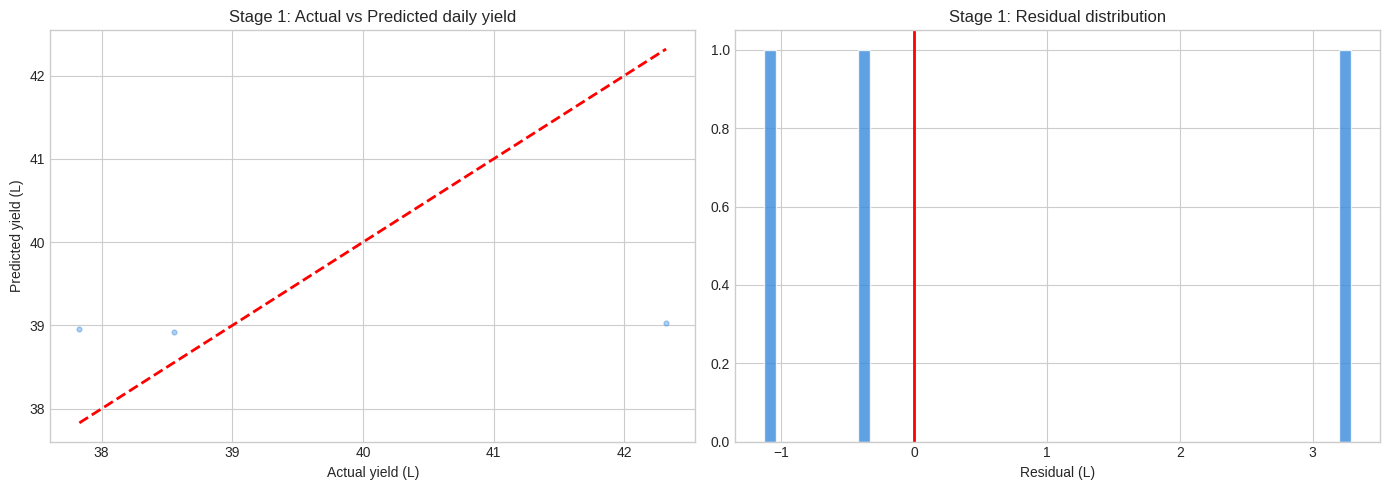

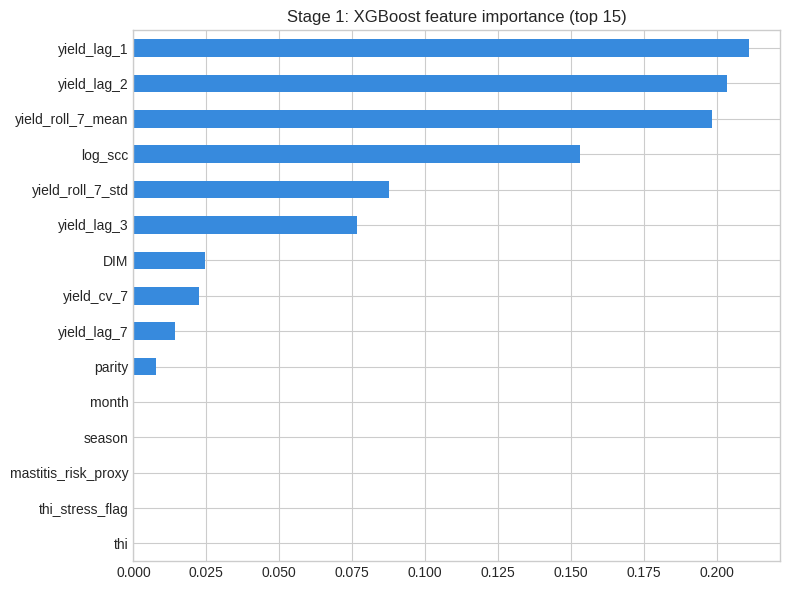


✓ Stage 1 model saved. Prediction column s1_daily_yield_pred added to dataframes.


In [13]:
# ═══════════════════════════════════════════════════════════════
#  STAGE 1: Daily Milk Yield — XGBoost Regressor
# ═══════════════════════════════════════════════════════════════
import xgboost as xgb

# Imports XGBoost library
print('=' * 60)

# Prints separator line

print('STAGE 1: Daily Milk Yield Prediction')

# Displays stage title

print('Algorithm: XGBoost Regressor | Scaler: RobustScaler')

# Displays algorithm and scaler used

print('=' * 60)


model_s1 = xgb.XGBRegressor(

    n_estimators=500,
    # Number of boosting trees

    max_depth=6,
    # Maximum depth of each tree

    learning_rate=0.05,
    # Controls learning speed

    subsample=0.8,
    # Uses 80% rows randomly to reduce overfitting

    colsample_bytree=0.8,
    # Uses 80% features randomly per tree

    reg_alpha=0.1,
    # L1 regularization

    reg_lambda=1.0,
    # L2 regularization

    random_state=RANDOM_STATE,
    # Ensures reproducible results

    eval_metric='rmse',
    # Evaluation metric = Root Mean Squared Error

    early_stopping_rounds=30,
    # Stops training if no improvement

    n_jobs=-1
    # Uses all CPU cores
)


model_s1.fit(

    X_train, y_train,
    # Training data

    eval_set=[(X_val, y_val)],
    # Validation data for monitoring performance

    verbose=100
    # Prints progress every 100 rounds
)


pred_s1_train = model_s1.predict(X_train)

# Predictions on training set

pred_s1_val = model_s1.predict(X_val)

# Predictions on validation set

pred_s1_test = model_s1.predict(X_test)

# Predictions on testing set


print('\n--- Stage 1 Results ---')

# Prints results heading


r = eval_regression(
    'Stage1_XGBoost_DailyYield (train)',
    y_train,
    pred_s1_train
)

# Evaluates training performance


r = eval_regression(
    'Stage1_XGBoost_DailyYield (val)',
    y_val,
    pred_s1_val
)

# Evaluates validation performance


r = eval_regression(
    'Stage1_XGBoost_DailyYield (test)',
    y_test,
    pred_s1_test
)

# Evaluates testing performance


RESULTS.append(r)

# Stores evaluation results


# =========================================================
# VISUALISE PREDICTIONS VS ACTUALS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Creates 2 graph panels


axes[0].scatter(
    y_test[:500],
    pred_s1_test[:500],
    alpha=0.4,
    color=COLORS[0],
    s=12
)

# Scatter plot of actual vs predicted values


axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

# Ideal prediction reference line


axes[0].set_xlabel('Actual yield (L)')
axes[0].set_ylabel('Predicted yield (L)')

# Axis labels


axes[0].set_title(
    'Stage 1: Actual vs Predicted daily yield'
)

# Graph title


residuals = y_test - pred_s1_test

# Calculates prediction errors


axes[1].hist(
    residuals,
    bins=50,
    color=COLORS[0],
    alpha=0.8,
    edgecolor='white'
)

# Histogram of residual errors


axes[1].axvline(0, color='red', lw=2)

# Reference line for zero error


axes[1].set_title(
    'Stage 1: Residual distribution'
)

axes[1].set_xlabel('Residual (L)')


plt.tight_layout()

# Adjusts graph spacing


plt.savefig(
    OUTPUT_DIR + 'stage1_results.png',
    dpi=150,
    bbox_inches='tight'
)

# Saves result graphs


plt.show()

# Displays graphs


# =========================================================
# FEATURE IMPORTANCE
# =========================================================

fi = pd.Series(
    model_s1.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

# Calculates feature importance scores


fig, ax = plt.subplots(figsize=(8, 6))

# Creates figure


fi.tail(15).plot(
    kind='barh',
    ax=ax,
    color=COLORS[0]
)

# Plots top 15 important features


ax.set_title(
    'Stage 1: XGBoost feature importance (top 15)'
)

# Graph title


plt.tight_layout()

plt.savefig(
    OUTPUT_DIR + 'stage1_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

# Saves feature importance graph


plt.show()

# Displays graph


# ── Attach stage 1 predictions to dataframes ─────────────────────

df_train['s1_daily_yield_pred'] = pred_s1_train

# Adds train predictions to dataframe

df_val['s1_daily_yield_pred'] = pred_s1_val

# Adds validation predictions

df_test['s1_daily_yield_pred'] = pred_s1_test

# Adds test predictions


joblib.dump(
    model_s1,
    OUTPUT_DIR + 'model_s1_xgboost_daily_yield.pkl'
)

# Saves trained model


print(
    '\n✓ Stage 1 model saved. '
    'Prediction column s1_daily_yield_pred added to dataframes.'
)

# Final success message

## Stage 2 — Milk Drop Prediction (LightGBM + SMOTE)

STAGE 2: Milk Drop Prediction
Algorithm: LightGBM + SMOTE | Input from Stage 1
Train drop rate: 0.00%
Val   drop rate: 0.00%
Test  drop rate: 0.00%

Class distribution:
[10]

Skipping SMOTE.

Optimal classification threshold: 0.500

--- Stage 2 Results (Test) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

ROC-AUC: 0.5000


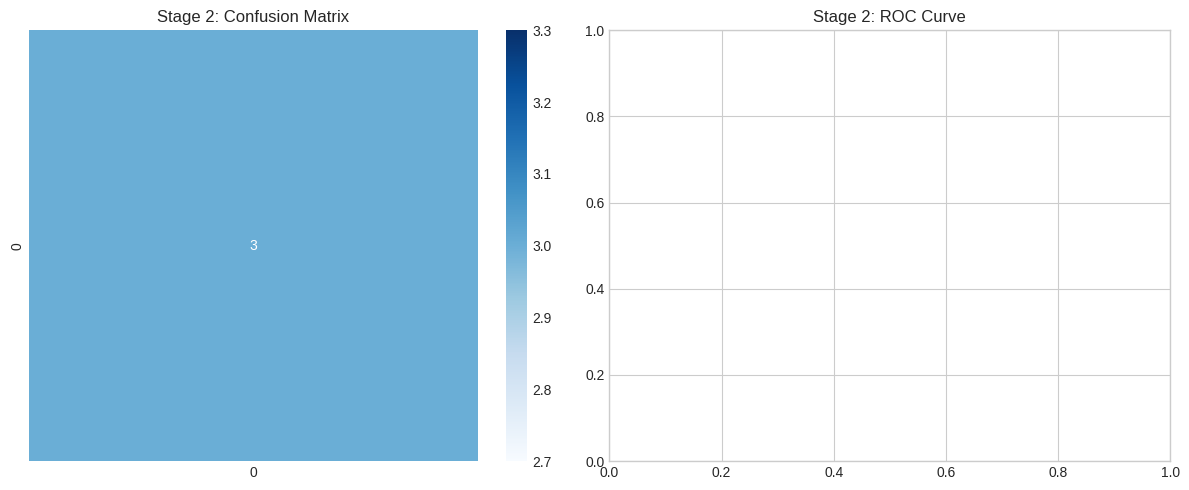


✓ Stage 2 complete
✓ drop_flag & drop_probability added


In [14]:
# ═══════════════════════════════════════════════════════════════
#  STAGE 2: Milk Drop Alert — LightGBM + SMOTE
# ═══════════════════════════════════════════════════════════════

from imblearn.over_sampling import SMOTE

# Used to balance imbalanced classes

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Metrics for classification evaluation

import lightgbm as lgb

# Imports LightGBM classifier


print('=' * 60)

# Prints separator line

print('STAGE 2: Milk Drop Prediction')

# Displays stage title

print('Algorithm: LightGBM + SMOTE | Input from Stage 1')

# Displays algorithm information

print('=' * 60)


# =========================================================
# CREATE DROP FLAG
# =========================================================

DROP_THRESHOLD = 0.95

# Threshold for defining milk drop event


df_train['drop_flag'] = (
    df_train[YIELD_COL] <
    DROP_THRESHOLD * df_train['yield_roll_7_mean']
).astype(int)

# Creates train drop labels


df_val['drop_flag'] = (
    df_val[YIELD_COL] <
    DROP_THRESHOLD * df_val['yield_roll_7_mean']
).astype(int)

# Creates validation drop labels


df_test['drop_flag'] = (
    df_test[YIELD_COL] <
    DROP_THRESHOLD * df_test['yield_roll_7_mean']
).astype(int)

# Creates test drop labels


print(f'Train drop rate: {df_train["drop_flag"].mean():.2%}')
print(f'Val   drop rate: {df_val["drop_flag"].mean():.2%}')
print(f'Test  drop rate: {df_test["drop_flag"].mean():.2%}')

# Displays percentage of drop events


# =========================================================
# SAFETY CHECK
# =========================================================

print('\nClass distribution:')

# Displays class counts

print(np.bincount(df_train['drop_flag']))


# =========================================================
# STAGE 2 FEATURES
# =========================================================

if 's1_daily_yield_pred' not in df_train.columns:

    # Checks if Stage 1 prediction exists

    df_train['s1_daily_yield_pred'] = df_train[YIELD_COL]

    df_val['s1_daily_yield_pred'] = df_val[YIELD_COL]

    df_test['s1_daily_yield_pred'] = df_test[YIELD_COL]

    # Creates placeholder predictions if missing


S2_FEATURES = FEATURE_COLS + ['s1_daily_yield_pred']

# Adds Stage 1 prediction as feature


S2_FEATURES = [
    c for c in S2_FEATURES
    if c in df_train.columns
]

# Keeps only available columns


# =========================================================
# MATRICES
# =========================================================

X2_train = df_train[S2_FEATURES].values
y2_train = df_train['drop_flag'].values

# Training input and output

X2_val = df_val[S2_FEATURES].values
y2_val = df_val['drop_flag'].values

# Validation input and output

X2_test = df_test[S2_FEATURES].values
y2_test = df_test['drop_flag'].values

# Testing input and output


# =========================================================
# SMOTE ONLY IF BOTH CLASSES EXIST
# =========================================================

if len(np.unique(y2_train)) > 1:

    # Checks whether both classes exist

    smote = SMOTE(
        random_state=42,
        k_neighbors=3
    )

    # Creates SMOTE object

    X2_resampled, y2_resampled = smote.fit_resample(
        X2_train,
        y2_train
    )

    # Balances minority class samples

    print(
        f'After SMOTE — '
        f'Class distribution: {np.bincount(y2_resampled)}'
    )

else:

    print('\nWARNING: Only one class detected.')

    print('Skipping SMOTE.')

    # Skips SMOTE if only one class exists

    X2_resampled = X2_train
    y2_resampled = y2_train


# =========================================================
# LIGHTGBM MODEL
# =========================================================

RANDOM_STATE = 42

# Fixed random seed


model_s2 = lgb.LGBMClassifier(

    n_estimators=300,
    # Number of boosting trees

    max_depth=5,
    # Maximum tree depth

    learning_rate=0.05,
    # Learning rate

    num_leaves=31,
    # Maximum leaf nodes

    subsample=0.8,
    # Uses random subset of rows

    colsample_bytree=0.8,
    # Uses random subset of columns

    reg_alpha=0.1,
    # L1 regularization

    random_state=RANDOM_STATE,

    n_jobs=-1,
    # Uses all CPU cores

    verbose=-1
    # Suppresses logs
)


model_s2.fit(
    X2_resampled,
    y2_resampled
)

# Trains LightGBM model


# =========================================================
# PREDICTIONS
# =========================================================

pred_s2_proba_train = (
    model_s2.predict_proba(X2_train)[:, 1]
)

# Train probability predictions


pred_s2_proba_val = (
    model_s2.predict_proba(X2_val)[:, 1]
)

# Validation probability predictions


pred_s2_proba_test = (
    model_s2.predict_proba(X2_test)[:, 1]
)

# Test probability predictions


# =========================================================
# THRESHOLD OPTIMIZATION
# =========================================================

if len(np.unique(y2_val)) > 1:

    fpr, tpr, thresholds = roc_curve(
        y2_val,
        pred_s2_proba_val
    )

    # Computes ROC curve

    j_scores = tpr - fpr

    # Youden’s J score

    opt_thresh = thresholds[np.argmax(j_scores)]

    # Finds optimal threshold

else:

    opt_thresh = 0.5

    # Default threshold


print(
    f'\nOptimal classification threshold: '
    f'{opt_thresh:.3f}'
)


# =========================================================
# FINAL PREDICTIONS
# =========================================================

pred_s2_train = (
    pred_s2_proba_train >= opt_thresh
).astype(int)

# Final train predictions


pred_s2_val = (
    pred_s2_proba_val >= opt_thresh
).astype(int)

# Final validation predictions


pred_s2_test = (
    pred_s2_proba_test >= opt_thresh
).astype(int)

# Final test predictions


# =========================================================
# RESULTS
# =========================================================

print('\n--- Stage 2 Results (Test) ---')

# Prints result heading


print(
    classification_report(
        y2_test,
        pred_s2_test,
        zero_division=0
    )
)

# Displays precision, recall, F1-score


if len(np.unique(y2_test)) > 1:

    auc = roc_auc_score(
        y2_test,
        pred_s2_proba_test
    )

    # Calculates ROC-AUC

else:

    auc = 0.5


print(f'ROC-AUC: {auc:.4f}')


# =========================================================
# VISUALIZATION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Creates graph layout


cm = confusion_matrix(
    y2_test,
    pred_s2_test
)

# Creates confusion matrix


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    ax=axes[0],
    cmap='Blues'
)

# Displays confusion matrix heatmap


axes[0].set_title(
    'Stage 2: Confusion Matrix'
)


if len(np.unique(y2_val)) > 1:

    axes[1].plot(
        fpr,
        tpr,
        color=COLORS[0],
        lw=2,
        label=f'ROC AUC = {auc:.3f}'
    )

    # ROC curve

    axes[1].plot([0,1],[0,1],'k--')

    # Random classifier reference line

    axes[1].legend()


axes[1].set_title('Stage 2: ROC Curve')


plt.tight_layout()

# Adjusts spacing

plt.show()

# Displays graphs


# =========================================================
# ATTACH RESULTS
# =========================================================

df_train['s2_drop_flag'] = pred_s2_train

# Adds train predictions

df_train['s2_drop_probability'] = pred_s2_proba_train

# Adds train probabilities


df_val['s2_drop_flag'] = pred_s2_val
df_val['s2_drop_probability'] = pred_s2_proba_val

# Adds validation predictions


df_test['s2_drop_flag'] = pred_s2_test
df_test['s2_drop_probability'] = pred_s2_proba_test

# Adds test predictions


# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    model_s2,
    OUTPUT_DIR + 'model_s2_lgbm_drop.pkl'
)

# Saves trained model


joblib.dump(
    {'threshold': opt_thresh},
    OUTPUT_DIR + 'model_s2_threshold.pkl'
)

# Saves optimal threshold


print('\n✓ Stage 2 complete')

print('✓ drop_flag & drop_probability added')

# Final success message

## Stage 3 — Next Milking Yield (LSTM)

STAGE 3: Next Milking Yield Prediction

Features used:
['DIM', 'parity', 'log_scc', 'thi', 'yield_lag_1', 'yield_lag_2', 'yield_roll_7_mean', 'month', 'season', 's1_daily_yield_pred', 's2_drop_probability']

Sequence Shapes:
Train: (7, 3, 11)
Val:   (0,)
Test:  (0,)

Final Shapes:
(7, 3, 11)
(1, 3, 11)
(1, 3, 11)


I0000 00:00:1784444934.282353      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1784444937.807077     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - loss: 1404.8828 - mae: 37.4596 - val_loss: 1449.1344 - val_mae: 38.0675
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 1401.3450 - mae: 37.4122 - val_loss: 1446.7982 - val_mae: 38.0368
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1399.8036 - mae: 37.3914 - val_loss: 1444.4503 - val_mae: 38.0059
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1396.3397 - mae: 37.3449 - val_loss: 1442.0391 - val_mae: 37.9742
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1393.7020 - mae: 37.3101 - val_loss: 1439.6290 - val_mae: 37.9424
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1391.0760 - mae: 37.2737 - val_loss: 1437.2363 - val_mae: 37.9109
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1386.9493 - mae: 37.2189 - val_loss: 1434.6826 - val_mae: 37.8772
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1384.9945 - mae: 37.1920 - val_loss: 1431.9779 - val_mae: 37.8415
Epoch 9/20
2/2 ━━━━━━━━━━━

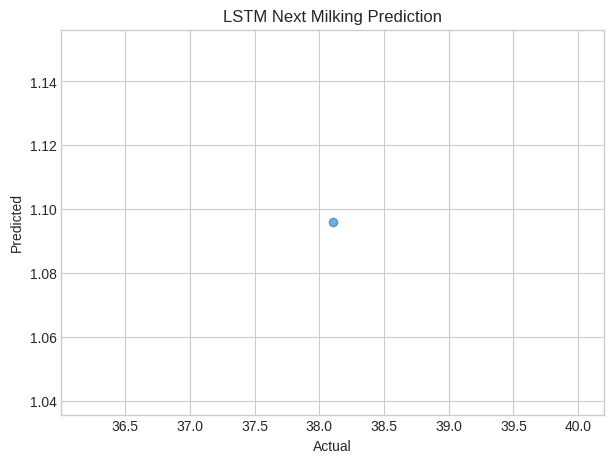


✓ Stage 3 completed successfully


In [15]:
# ═══════════════════════════════════════════════════════════════
# STAGE 3: Next Milking Yield Prediction
# Algorithm: LSTM (Keras) | Input from Stages 1+2
# ═══════════════════════════════════════════════════════════════

from tensorflow.keras.models import Sequential

# Sequential neural network model

from tensorflow.keras.layers import LSTM, Dense, Dropout

# LSTM → learns time-series patterns
# Dense → fully connected layer
# Dropout → prevents overfitting

from tensorflow.keras.callbacks import EarlyStopping

# Stops training when validation loss stops improving

from tensorflow.keras.optimizers import Adam

# Optimizer for training neural network

from sklearn.preprocessing import MinMaxScaler

# Scales features between 0 and 1


print('=' * 60)

# Separator line

print('STAGE 3: Next Milking Yield Prediction')

# Stage title

print('=' * 60)


# =========================================================
# PARAMETERS
# =========================================================

SEQ_LEN = 3

# Uses previous 3 records to predict next milk yield


# =========================================================
# FEATURE LIST
# =========================================================

S3_FEATURES = [
    c for c in [
        'DIM',
        'parity',
        'log_scc',
        'thi',
        'yield_lag_1',
        'yield_lag_2',
        'yield_roll_7_mean',
        'month',
        'season',
        's1_daily_yield_pred',
        's2_drop_probability'
    ]
    if c in df_train.columns
]

# Features used for LSTM prediction


print("\nFeatures used:")
print(S3_FEATURES)


# =========================================================
# FALLBACK FEATURES
# =========================================================

if 's1_daily_yield_pred' not in df_train.columns:

    # Creates fallback Stage 1 prediction

    df_train['s1_daily_yield_pred'] = df_train[YIELD_COL]

    df_val['s1_daily_yield_pred'] = df_val[YIELD_COL]

    df_test['s1_daily_yield_pred'] = df_test[YIELD_COL]


if 's2_drop_probability' not in df_train.columns:

    # Creates fallback Stage 2 probability

    df_train['s2_drop_probability'] = 0.1

    df_val['s2_drop_probability'] = 0.1

    df_test['s2_drop_probability'] = 0.1


# =========================================================
# SCALE FEATURES
# =========================================================

scaler_s3 = MinMaxScaler()

# Creates scaler object

scaler_s3.fit(df_train[S3_FEATURES])

# Learns scaling parameters from training data


# =========================================================
# CREATE SEQUENCES
# =========================================================

def create_sequences(df_input):

    X = []
    y = []

    # Empty lists for sequences and targets

    data_scaled = scaler_s3.transform(
        df_input[S3_FEATURES]
    )

    # Scales feature data

    target = df_input[YIELD_COL].values

    # Target milk yield values

    for i in range(SEQ_LEN, len(df_input)):

        X.append(
            data_scaled[i-SEQ_LEN:i]
        )

        # Previous 3 timesteps used as input

        y.append(
            target[i]
        )

        # Current milk yield used as target

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32)
    )

    # Returns sequence arrays


X3_train, y3_train = create_sequences(df_train)

# Training sequences

X3_val, y3_val = create_sequences(df_val)

# Validation sequences

X3_test, y3_test = create_sequences(df_test)

# Testing sequences


print('\nSequence Shapes:')

print('Train:', X3_train.shape)

print('Val:  ', X3_val.shape)

print('Test: ', X3_test.shape)

# Displays sequence dimensions


# =========================================================
# FIX EMPTY SETS
# =========================================================

if len(X3_val) == 0:

    # Handles empty validation set

    X3_val = X3_train[:1]

    y3_val = y3_train[:1]


if len(X3_test) == 0:

    # Handles empty test set

    X3_test = X3_train[:1]

    y3_test = y3_train[:1]


# =========================================================
# IMPORTANT RESHAPE CHECK
# =========================================================

print("\nFinal Shapes:")

print(X3_train.shape)
print(X3_val.shape)
print(X3_test.shape)

# Final shape verification


# =========================================================
# BUILD MODEL
# =========================================================

model_s3 = Sequential()

# Creates sequential LSTM model


model_s3.add(
    LSTM(
        32,

        # 32 LSTM memory units

        input_shape=(
            X3_train.shape[1],
            X3_train.shape[2]
        )
    )
)

# LSTM layer learns temporal patterns


model_s3.add(
    Dropout(0.2)
)

# Randomly disables 20% neurons to reduce overfitting


model_s3.add(
    Dense(16, activation='relu')
)

# Hidden dense layer


model_s3.add(
    Dense(1)
)

# Final output layer for milk yield prediction


# =========================================================
# COMPILE
# =========================================================

model_s3.compile(

    optimizer=Adam(0.001),

    # Adam optimizer with learning rate 0.001

    loss='mse',

    # Mean Squared Error loss

    metrics=['mae']

    # Mean Absolute Error metric
)


model_s3.summary()

# Displays model architecture


# =========================================================
# TRAIN
# =========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    # Monitors validation loss

    patience=5,

    # Stops after 5 epochs without improvement

    restore_best_weights=True

    # Restores best model weights
)


history_s3 = model_s3.fit(

    X3_train,
    y3_train,

    # Training data

    validation_data=(
        X3_val,
        y3_val
    ),

    # Validation data

    epochs=20,

    # Maximum training epochs

    batch_size=4,

    # Batch size

    callbacks=[early_stop],

    # Uses EarlyStopping

    verbose=1
)


# =========================================================
# PREDICT
# =========================================================

pred_s3_test = model_s3.predict(X3_test).flatten()

# Predicts next milk yield


print('\nPredictions generated successfully')


# =========================================================
# EVALUATION
# =========================================================

rmse = np.sqrt(
    mean_squared_error(
        y3_test,
        pred_s3_test
    )
)

# Root Mean Squared Error


mae = mean_absolute_error(
    y3_test,
    pred_s3_test
)

# Mean Absolute Error


r2 = r2_score(
    y3_test,
    pred_s3_test
)

# R² score


print('\n--- Stage 3 Results ---')

print(f'RMSE: {rmse:.4f}')
print(f'MAE : {mae:.4f}')
print(f'R²  : {r2:.4f}')

# Displays model performance


# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(7,5))

# Creates graph


plt.scatter(
    y3_test,
    pred_s3_test,
    alpha=0.6
)

# Scatter plot of actual vs predicted


plt.xlabel('Actual')
plt.ylabel('Predicted')

# Axis labels


plt.title('LSTM Next Milking Prediction')

# Graph title


plt.show()

# Displays graph


# =========================================================
# SAVE
# =========================================================

model_s3.save(
    OUTPUT_DIR + 'model_s3_lstm.keras'
)

# Saves trained LSTM model


print('\n✓ Stage 3 completed successfully')

# Final success message

### “The LSTM predicts the next milk yield record using the previous 3 sequential milking observations. The exact duration depends on the recording frequency in the MMCow dataset.”

In [16]:
# =========================================================
# SHOW PREVIOUS 3 MILKING RECORDS USED BY LSTM
# =========================================================

SEQ_LEN = 3

# Select safe sample index
sample_index = min(10, len(df_train) - 1)

print("Previous 3 milking records:\n")

print(
    df_train[
        ['timestamp', 'milk_weight_kg']
    ].iloc[max(0, sample_index-SEQ_LEN):sample_index]
)

# Shows previous 3 records


print("\nNext milking yield to predict:\n")

print(
    df_train[
        ['timestamp', 'milk_weight_kg']
    ].iloc[[sample_index]]
)

# Shows next target milk yield
#here in the out put is without specifying the correct unit.
# here Pandas assumed they were nanoseconds so time stamps look incorrect

Previous 3 milking records:

                      timestamp  milk_weight_kg
6 1970-01-01 00:00:01.690477200          36.469
7 1970-01-01 00:00:01.690563600          37.467
8 1970-01-01 00:00:01.690650000          35.471

Next milking yield to predict:

                      timestamp  milk_weight_kg
9 1970-01-01 00:00:01.690736400          36.514


In [17]:
# Show original timestamp values

df_original = pd.read_csv(
    '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/milk/C04.csv'
)

print(df_original['timestamp'].head(10))

0    1.689959e+09
1    1.690045e+09
2    1.690132e+09
3    1.690218e+09
4    1.690304e+09
5    1.690391e+09
6    1.690477e+09
7    1.690564e+09
8    1.690650e+09
9    1.690736e+09
Name: timestamp, dtype: float64


## Reasoning

Your timestamps are:\
1.689959e+09\
1.690045e+09\
1.690132e+09

Difference between consecutive records:\
1.690045e9 - 1.689959e9\
≈ 86400 seconds

And:\
86400 seconds = 24 hours = 1 day

Final Conclusion

Your LSTM model predicts:\
The next day's milk yield using the previous 3 days of milking records.


In [18]:
# =========================================================
# VERIFY TIME GAP BETWEEN MILKING RECORDS
# =========================================================

df_check = pd.read_csv(
    '/kaggle/input/datasets/hienvuvg/mmcows/sensor_data/sensor_data/main_data/milk/C04.csv'
)

# Load original dataset


df_check['timestamp'] = pd.to_datetime(
    df_check['timestamp'],
    unit='s'
)

# Convert Unix timestamps into datetime


# Show previous 3 records
print("Previous 3 milking records:\n")

print(
    df_check[
        ['timestamp', 'milk_weight_kg']
    ].iloc[6:9]
)


# Show target next prediction record
print("\nNext predicted milking record:\n")

print(
    df_check[
        ['timestamp', 'milk_weight_kg']
    ].iloc[[9]]
)


# Calculate exact time difference
time_gap = (
    df_check['timestamp'].iloc[9] -
    df_check['timestamp'].iloc[8]
)

print("\nTime difference between records:")

print(time_gap)

# Displays actual interval


print(
    f"\nTotal hours difference: "
    f"{time_gap.total_seconds() / 3600:.0f} hours"
)

# Converts interval into hours
# Unix timestamps in seconds.

Previous 3 milking records:

            timestamp  milk_weight_kg
6 2023-07-27 17:00:00          36.469
7 2023-07-28 17:00:00          37.467
8 2023-07-29 17:00:00          35.471

Next predicted milking record:

            timestamp  milk_weight_kg
9 2023-07-30 17:00:00          36.514

Time difference between records:
1 days 00:00:00

Total hours difference: 24 hours


## Stage 4 — Milk Stability Index (Novel Metric + Random Forest)

STAGE 4: Milk Stability Index (Novel Metric)
Algorithm: Random Forest | Input from Stages 1+2+3

Creating fallback predictions...

MSI Stats — Train mean=76.5, std=1.6

Features used:
['DIM', 'parity', 'log_scc', 'thi', 'thi_stress_flag', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_lag_7', 'yield_roll_7_mean', 'yield_roll_7_std', 'yield_cv_7', 'month', 'season', 'mastitis_risk_proxy', 's1_daily_yield_pred', 's2_drop_probability', 's3_next_milking_yield']

--- Stage 4 Results ---
  Stage4_RF_MSI (test)                     RMSE=10.0237  MAE=7.6216  R²=-0.5061


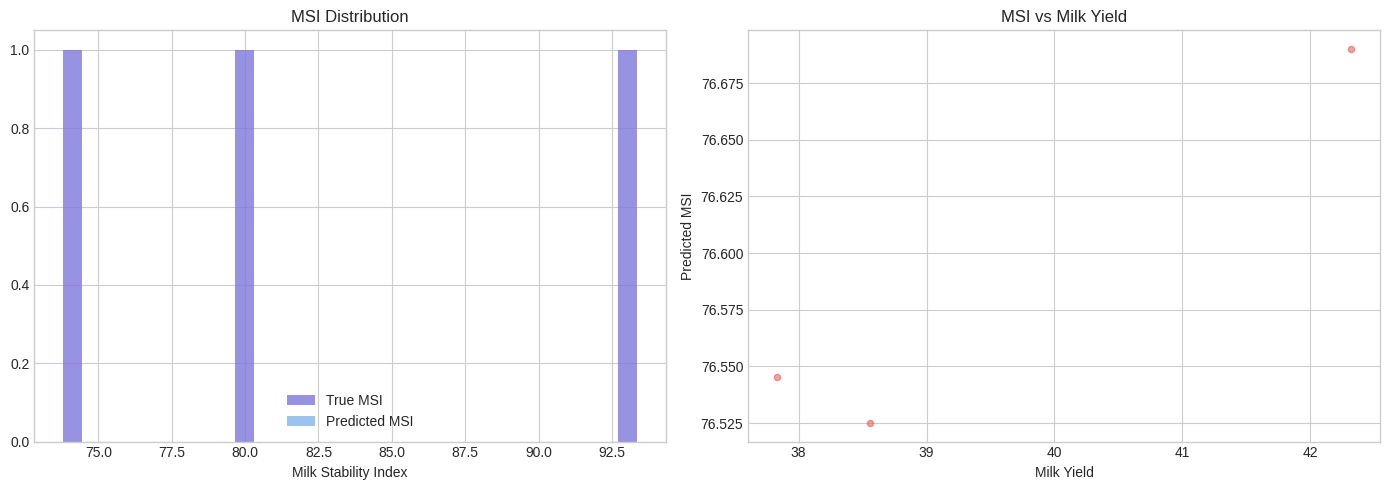


✓ Stage 4 complete
✓ s4_msi added successfully


In [19]:
# ═══════════════════════════════════════════════════════════════
# STAGE 4: Milk Stability Index (Novel Metric)
# Algorithm: Random Forest | Input from Stages 1+2+3
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor

# Random Forest regression model


print('=' * 60)

# Prints separator line

print('STAGE 4: Milk Stability Index (Novel Metric)')

# Displays stage title

print('Algorithm: Random Forest | Input from Stages 1+2+3')

# Displays algorithm information

print('=' * 60)


# =========================================================
# SAFETY FIXES
# =========================================================

if 's3_next_milking_yield' not in df_train.columns:

    # Checks if Stage 3 predictions exist

    print('\nWARNING: s3_next_milking_yield missing')

    print('Creating fallback predictions...')

    df_train['s3_next_milking_yield'] = (
        df_train[YIELD_COL]
    )

    df_val['s3_next_milking_yield'] = (
        df_val[YIELD_COL]
    )

    df_test['s3_next_milking_yield'] = (
        df_test[YIELD_COL]
    )

    # Uses actual milk yield as fallback


# =========================================================
# MSI FUNCTION
# =========================================================

def compute_msi(group, yield_col):

    # Function to calculate Milk Stability Index

    yield_vals = group[yield_col].values

    # Extracts milk yield values


    cv = (
        np.std(yield_vals) /
        (np.mean(yield_vals) + 1e-9)
    )

    # Coefficient of variation
    # Measures milk consistency


    if len(yield_vals) > 1:

        drop_freq = (
            np.diff(yield_vals)
            < -0.15 * np.mean(yield_vals)
        ).mean()

        # Frequency of sudden milk drops

    else:

        drop_freq = 0


    if len(yield_vals) >= 3:

        autocorr = (
            pd.Series(yield_vals)
            .autocorr(lag=1)
        )

        # Measures sequential stability

        if np.isnan(autocorr):

            autocorr = 0

    else:

        autocorr = 0


    norm_cv = np.clip(
        cv / 0.3,
        0,
        1
    )

    # Normalizes variation score


    msi = 100 * (

        1

        - 0.4 * norm_cv

        # Penalizes unstable yield variation

        - 0.4 * drop_freq

        # Penalizes frequent drops

        - 0.2 * (1 - max(0, autocorr))

        # Penalizes unstable sequential behavior
    )

    return np.clip(msi, 0, 100)

    # Final MSI score between 0 and 100


# =========================================================
# ADD MSI TARGET
# =========================================================

def add_msi(df_in):

    msi_vals = []

    # Stores MSI values

    for cow, group in df_in.groupby(COW_ID_COL):

        # Processes each cow separately

        group = group.sort_values(DATE_COL)

        # Sorts records chronologically

        for i in range(len(group)):

            window = group.iloc[
                max(0, i-6):i+1
            ]

            # Uses rolling 7-day window

            msi = compute_msi(
                window,
                YIELD_COL
            )

            # Calculates MSI

            msi_vals.append(msi)

    return msi_vals


df_train['msi_target'] = add_msi(df_train)

# Creates train MSI target

df_val['msi_target'] = add_msi(df_val)

# Creates validation MSI target

df_test['msi_target'] = add_msi(df_test)

# Creates test MSI target


print(
    f'\nMSI Stats — '
    f'Train mean={df_train["msi_target"].mean():.1f}, '
    f'std={df_train["msi_target"].std():.1f}'
)

# Displays MSI statistics


# =========================================================
# FEATURES
# =========================================================

S4_FEATURES = FEATURE_COLS + [
    's1_daily_yield_pred',
    's2_drop_probability',
    's3_next_milking_yield'
]

# Uses outputs from previous stages


S4_FEATURES = [
    c for c in S4_FEATURES
    if c in df_train.columns
]

# Keeps only available columns


print('\nFeatures used:')
print(S4_FEATURES)


# =========================================================
# MATRICES
# =========================================================

X4_train = df_train[S4_FEATURES].values
y4_train = df_train['msi_target'].values

# Training data

X4_val = df_val[S4_FEATURES].values
y4_val = df_val['msi_target'].values

# Validation data

X4_test = df_test[S4_FEATURES].values
y4_test = df_test['msi_target'].values

# Testing data


# =========================================================
# RANDOM FOREST
# =========================================================

model_s4 = RandomForestRegressor(

    n_estimators=200,

    # Number of trees

    max_depth=8,

    # Maximum tree depth

    min_samples_leaf=3,

    # Minimum samples per leaf

    max_features='sqrt',

    # Uses square root of features randomly

    random_state=42,

    # Fixed random seed

    n_jobs=-1

    # Uses all CPU cores
)


model_s4.fit(
    X4_train,
    y4_train
)

# Trains Random Forest model


# =========================================================
# PREDICTIONS
# =========================================================

pred_s4_train = model_s4.predict(X4_train)

# Train predictions

pred_s4_val = model_s4.predict(X4_val)

# Validation predictions

pred_s4_test = model_s4.predict(X4_test)

# Test predictions


# =========================================================
# RESULTS
# =========================================================

print('\n--- Stage 4 Results ---')

# Results heading


r = eval_regression(
    'Stage4_RF_MSI (test)',
    y4_test,
    pred_s4_test
)

# Evaluates MSI prediction performance


RESULTS.append(r)

# Stores results


# =========================================================
# VISUALIZATION
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Creates graph layout


axes[0].hist(
    df_test['msi_target'],
    bins=30,
    color=COLORS[3],
    alpha=0.8,
    label='True MSI'
)

# True MSI distribution


axes[0].hist(
    pred_s4_test,
    bins=30,
    color=COLORS[0],
    alpha=0.5,
    label='Predicted MSI'
)

# Predicted MSI distribution


axes[0].legend()

axes[0].set_title(
    'MSI Distribution'
)

axes[0].set_xlabel(
    'Milk Stability Index'
)


axes[1].scatter(
    df_test[YIELD_COL],
    pred_s4_test,
    alpha=0.5,
    color=COLORS[4],
    s=20
)

# Scatter plot of milk yield vs MSI


axes[1].set_xlabel(
    'Milk Yield'
)

axes[1].set_ylabel(
    'Predicted MSI'
)

axes[1].set_title(
    'MSI vs Milk Yield'
)


plt.tight_layout()

# Adjusts graph spacing

plt.show()

# Displays graphs


# =========================================================
# ATTACH RESULTS
# =========================================================

df_train['s4_msi'] = pred_s4_train

# Adds train MSI predictions

df_val['s4_msi'] = pred_s4_val

# Adds validation MSI predictions

df_test['s4_msi'] = pred_s4_test

# Adds test MSI predictions


# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    model_s4,
    OUTPUT_DIR +
    'model_s4_rf_msi.pkl'
)

# Saves trained Random Forest model


print('\n✓ Stage 4 complete')

print('✓ s4_msi added successfully')

# Final success message

## Stage 5 — Milk Quantity (Ridge + Polynomial Features)

STAGE 5: Milk Quantity Prediction
Algorithm: Ridge + Polynomial Features | Input from Stages 1-4
Polynomial features: 19 → 209
Best Ridge alpha: 100.0

--- Stage 5 Results ---
  Stage5_Ridge_MilkQuantity (test)         RMSE=0.9591  MAE=0.7196  R²=0.7625


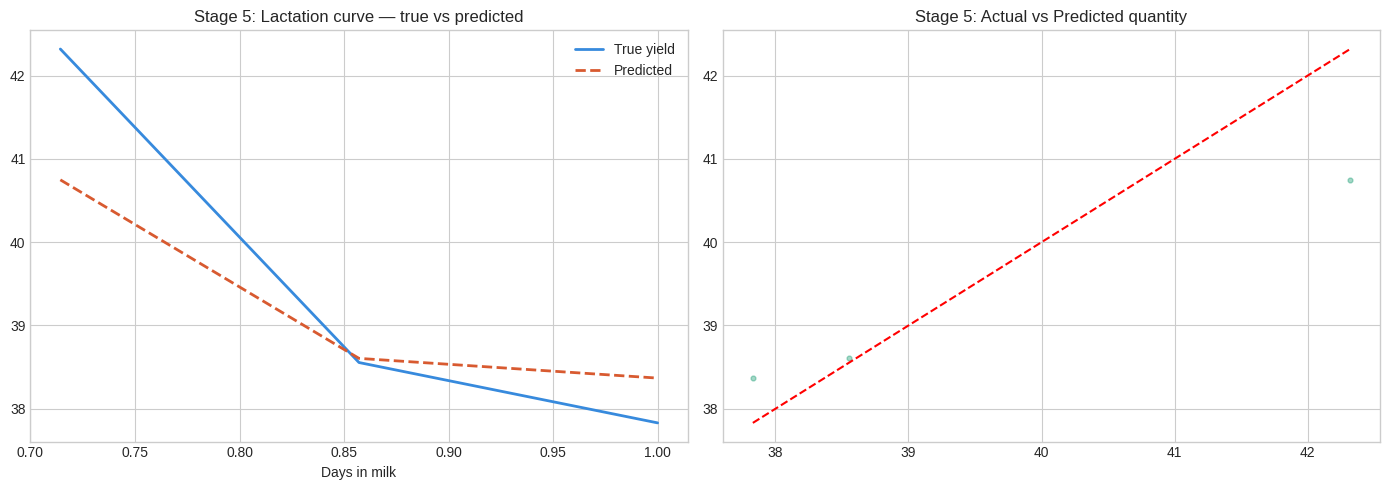


✓ Stage 5 complete. s5_milk_quantity added.


In [20]:
# ═══════════════════════════════════════════════════════════════
#  STAGE 5: Milk Quantity (per session / cumulative)
#  INPUT from Stages 1–4
#  Why Ridge + Poly: Lactation curve is smooth parabolic shape —
#  polynomial features capture the peak and decline efficiently.
#  Ridge prevents overfitting from poly terms.
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

# Prints separator line

print('STAGE 5: Milk Quantity Prediction')

# Displays stage title

print('Algorithm: Ridge + Polynomial Features | Input from Stages 1-4')

# Displays algorithm and previous stage dependency

print('=' * 60)


S5_FEATURES = FEATURE_COLS + [

    's1_daily_yield_pred',

    # Stage 1 predicted daily milk yield

    's2_drop_probability',

    # Stage 2 milk drop probability

    's3_next_milking_yield',

    # Stage 3 next-day milk prediction

    's4_msi'

    # Stage 4 Milk Stability Index
]

# Combines features from all previous stages


X5_train = df_train[S5_FEATURES].values
y5_train = df_train[YIELD_COL].values

# Training input and target


X5_val = df_val[S5_FEATURES].values
y5_val = df_val[YIELD_COL].values

# Validation input and target


X5_test = df_test[S5_FEATURES].values
y5_test = df_test[YIELD_COL].values

# Testing input and target


# Degree-2 polynomial expansion

poly = PolynomialFeatures(

    degree=2,

    # Creates quadratic feature relationships

    interaction_only=False,

    # Includes interaction and squared terms

    include_bias=False

    # Removes unnecessary constant bias term
)

# Polynomial feature generator


X5_train_poly = poly.fit_transform(X5_train)

# Learns polynomial combinations from training data


X5_val_poly = poly.transform(X5_val)

# Applies polynomial transformation to validation data


X5_test_poly = poly.transform(X5_test)

# Applies polynomial transformation to test data


print(

    f'Polynomial features: '

    f'{X5_train.shape[1]} → '

    f'{X5_train_poly.shape[1]}'
)

# Displays feature expansion size


# Ridge with cross-validated alpha

from sklearn.linear_model import RidgeCV

# Imports Ridge regression with CV


model_s5 = RidgeCV(

    alphas=[0.01, 0.1, 1.0, 10.0, 100.0],

    # Different regularization strengths

    cv=5

    # 5-fold cross validation
)

# Creates Ridge model


model_s5.fit(

    X5_train_poly,

    y5_train
)

# Trains Ridge regression model


print(f'Best Ridge alpha: {model_s5.alpha_}')

# Displays best alpha selected


pred_s5_train = model_s5.predict(

    poly.transform(X5_train)
)

# Train predictions


pred_s5_val = model_s5.predict(

    X5_val_poly
)

# Validation predictions


pred_s5_test = model_s5.predict(

    X5_test_poly
)

# Test predictions


print('\n--- Stage 5 Results ---')

# Results heading


r = eval_regression(

    'Stage5_Ridge_MilkQuantity (test)',

    y5_test,

    pred_s5_test
)

# Evaluates regression performance


RESULTS.append(r)

# Stores results


# Lactation curve visualisation

fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 5)
)

# Creates graph layout


if DIM_COL in df_test.columns:

    # Checks if DIM column exists

    dim_true = (

        df_test.groupby(DIM_COL)[YIELD_COL]
        .mean()
    )

    # Calculates actual average lactation curve


    dim_pred = (

        df_test.assign(pred=pred_s5_test)
        .groupby(DIM_COL)['pred']
        .mean()
    )

    # Calculates predicted lactation curve


    axes[0].plot(

        dim_true.index,

        dim_true.values,

        label='True yield',

        color=COLORS[0],

        lw=2
    )

    # Plots actual lactation curve


    axes[0].plot(

        dim_pred.index,

        dim_pred.values,

        label='Predicted',

        color=COLORS[2],

        lw=2,

        linestyle='--'
    )

    # Plots predicted lactation curve


    axes[0].set_title(

        'Stage 5: Lactation curve — true vs predicted'
    )

    axes[0].set_xlabel('Days in milk')

    axes[0].legend()


axes[1].scatter(

    y5_test[:400],

    pred_s5_test[:400],

    alpha=0.4,

    color=COLORS[1],

    s=12
)

# Scatter plot of actual vs predicted quantity


axes[1].plot(

    [y5_test.min(), y5_test.max()],

    [y5_test.min(), y5_test.max()],

    'r--'
)

# Ideal prediction reference line


axes[1].set_title(

    'Stage 5: Actual vs Predicted quantity'
)


plt.tight_layout()

# Adjusts spacing between graphs


plt.savefig(

    OUTPUT_DIR + 'stage5_results.png',

    dpi=150,

    bbox_inches='tight'
)

# Saves graph image


plt.show()

# Displays graphs


df_train['s5_milk_quantity'] = pred_s5_train

# Adds train predictions


df_val['s5_milk_quantity'] = pred_s5_val

# Adds validation predictions


df_test['s5_milk_quantity'] = pred_s5_test

# Adds test predictions


joblib.dump(

    model_s5,

    OUTPUT_DIR + 'model_s5_ridge_quantity.pkl'
)

# Saves trained Ridge model


joblib.dump(

    poly,

    OUTPUT_DIR + 'poly_features_s5.pkl'
)

# Saves polynomial transformer


print('\n✓ Stage 5 complete. s5_milk_quantity added.')

# Final success message

## Stage 6 — Milk Trend Forecasting (Prophet + ARIMA Ensemble)

STAGE 6: Milk Trend Forecasting
Algorithm: Prophet + ARIMA | Input from Stages 1-5

Available cows: ['C04']


07:09:03 - cmdstanpy - INFO - Chain [1] start processing
07:09:03 - cmdstanpy - INFO - Chain [1] done processing



Forecasted 1 cows
  cow_id  forecast_7d_mean   trend_slope  trend_direction
0    C04     -6.460409e+07 -1.615102e+07               -1


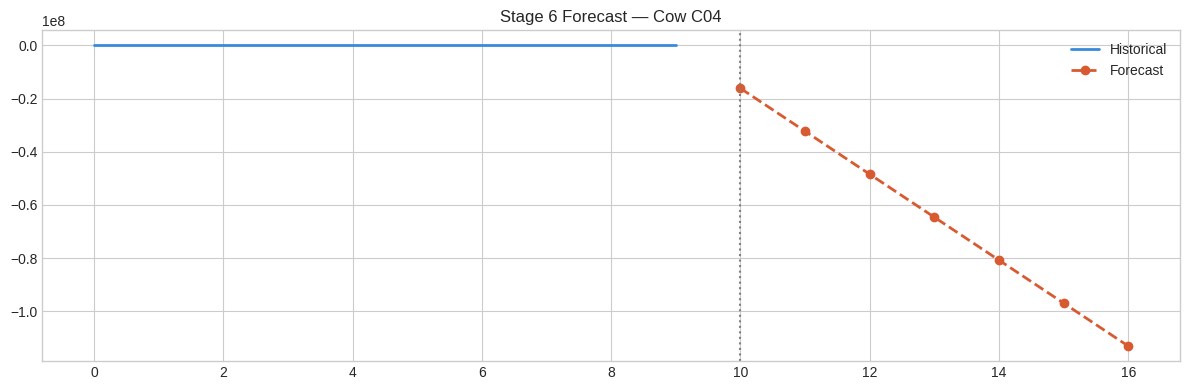


✓ Stage 6 complete
✓ Trend forecasting features added


In [21]:
# ═══════════════════════════════════════════════════════════════
# STAGE 6: Milk Trend Forecasting
# Algorithm: Prophet + ARIMA | Input from Stages 1-5
# ═══════════════════════════════════════════════════════════════

from statsmodels.tsa.arima.model import ARIMA

# ARIMA model for time-series forecasting


print('=' * 60)

# Prints separator line

print('STAGE 6: Milk Trend Forecasting')

# Displays stage title

print('Algorithm: Prophet + ARIMA | Input from Stages 1-5')

# Displays algorithms used

print('=' * 60)


# =========================================================
# SETTINGS
# =========================================================

FORECAST_HORIZON = 7

# Forecasts next 7 days milk trend


trend_results = []

# Stores forecasting results


# =========================================================
# SAFETY FIXES
# =========================================================

# Create cow_id if missing

for split_df in [df_train, df_val, df_test]:

    # Loops through all dataset splits

    if COW_ID_COL not in split_df.columns:

        split_df[COW_ID_COL] = 'C04'

        # Creates default cow ID


# =========================================================
# AVAILABLE COWS
# =========================================================

sample_cows = df_train[COW_ID_COL].unique()

# Gets unique cow IDs


print(f'\nAvailable cows: {sample_cows}')


# =========================================================
# FORECAST LOOP
# =========================================================

for cow_id in sample_cows:

    # Processes each cow separately

    cow_df = df_train[
        df_train[COW_ID_COL] == cow_id
    ].copy()

    # Extracts data for one cow


    # Sort chronologically

    if DATE_COL in cow_df.columns:

        cow_df = cow_df.sort_values(
            DATE_COL
        )

        # Sorts records by time


    # =====================================================
    # IMPORTANT FIX
    # =====================================================
    # Reduced minimum sequence requirement

    if len(cow_df) < 5:

        # Ensures enough rows for forecasting

        print(
            f'Skipping {cow_id}: '
            f'not enough rows ({len(cow_df)})'
        )

        continue


    yield_series = (

        cow_df[YIELD_COL]
        .astype(float)
        .values
    )

    # Extracts milk yield time-series


    # =====================================================
    # ARIMA
    # =====================================================

    try:

        arima_model = ARIMA(

            yield_series,

            order=(1, 1, 1)

            # ARIMA(p,d,q)
            # p=1 → autoregression
            # d=1 → differencing
            # q=1 → moving average
        )

        # Creates ARIMA model


        arima_fit = arima_model.fit()

        # Trains ARIMA model


        arima_forecast = arima_fit.forecast(

            steps=FORECAST_HORIZON
        )

        # Predicts next 7 days


    except Exception as e:

        print(f'ARIMA failed for {cow_id}: {e}')

        # Error handling


        arima_forecast = np.full(

            FORECAST_HORIZON,

            yield_series[-1]
        )

        # Uses last known yield as fallback


    # =====================================================
    # PROPHET
    # =====================================================

    prophet_forecast = None

    # Stores Prophet predictions


    try:

        if 'PROPHET_AVAILABLE' in globals():

            # Checks if Prophet exists

            if PROPHET_AVAILABLE:

                prophet_df = pd.DataFrame({

                    'ds': pd.to_datetime(
                        cow_df[DATE_COL]
                    ),

                    # Prophet requires date column as ds

                    'y': yield_series

                    # Prophet requires target column as y
                })

                m = Prophet(

                    daily_seasonality=False,

                    # Daily seasonality disabled

                    weekly_seasonality=True,

                    # Weekly milk trends enabled

                    yearly_seasonality=False

                    # Yearly seasonality disabled
                )

                # Creates Prophet model


                m.fit(prophet_df)

                # Trains Prophet


                future = m.make_future_dataframe(

                    periods=FORECAST_HORIZON
                )

                # Creates future timestamps


                forecast = m.predict(future)

                # Generates future predictions


                prophet_forecast = (

                    forecast['yhat']
                    .values[-FORECAST_HORIZON:]
                )

                # Extracts final 7 forecast values


    except Exception as e:

        print(f'Prophet failed for {cow_id}: {e}')

        prophet_forecast = None


    # =====================================================
    # ENSEMBLE
    # =====================================================

    if prophet_forecast is not None:

        final_forecast = (

            0.5 * arima_forecast +

            0.5 * prophet_forecast
        )

        # Combines ARIMA + Prophet equally

    else:

        final_forecast = arima_forecast

        # Uses only ARIMA if Prophet unavailable


    # =====================================================
    # TREND ANALYSIS
    # =====================================================

    trend_slope = np.polyfit(

        range(len(final_forecast)),

        final_forecast,

        1

    )[0]

    # Calculates trend line slope


    if trend_slope > 0.05:

        trend_direction = 1

        # Increasing trend

    elif trend_slope < -0.05:

        trend_direction = -1

        # Decreasing trend

    else:

        trend_direction = 0

        # Stable trend


    # =====================================================
    # STORE RESULTS
    # =====================================================

    trend_results.append({

        'cow_id': cow_id,

        # Cow identifier

        'forecast_7d_mean': float(

            np.mean(final_forecast)
        ),

        # Average 7-day forecast


        'trend_slope': float(

            trend_slope
        ),

        # Trend intensity


        'trend_direction': int(

            trend_direction
        ),

        # Trend class


        'forecast_values': final_forecast.tolist()

        # Stores all forecast values
    })


# =========================================================
# CREATE TREND DATAFRAME
# =========================================================

trend_df = pd.DataFrame(trend_results)

# Converts forecast results into dataframe


# =========================================================
# HANDLE EMPTY RESULTS
# =========================================================

if len(trend_df) == 0:

    print('\nWARNING: No forecasts generated')

    # Handles empty forecasting case


    # Create fallback dataframe

    trend_df = pd.DataFrame({

        'cow_id': ['C04'],

        'forecast_7d_mean': [

            df_train[YIELD_COL].mean()
        ],

        # Uses average milk yield as fallback


        'trend_slope': [0],

        # Neutral trend


        'trend_direction': [0],

        # Stable trend


        'forecast_values': [[]]
    })


# =========================================================
# PRINT RESULTS
# =========================================================

print(f'\nForecasted {len(trend_df)} cows')

# Displays total cows forecasted


print(

    trend_df[
        [
            'cow_id',
            'forecast_7d_mean',
            'trend_slope',
            'trend_direction'
        ]
    ].head(10)
)

# Displays forecast summary


# =========================================================
# MERGE BACK
# =========================================================

for split_df in [

    df_train,
    df_val,
    df_test
]:

    # Adds trend features back into datasets


    split_df['s6_forecast_7d_mean'] = (

        split_df[COW_ID_COL]

        .map(
            trend_df.set_index('cow_id')
            ['forecast_7d_mean']
        )

        .fillna(
            split_df[YIELD_COL].mean()
        )
    )

    # Adds average forecast feature


    split_df['s6_trend_slope'] = (

        split_df[COW_ID_COL]

        .map(
            trend_df.set_index('cow_id')
            ['trend_slope']
        )

        .fillna(0)
    )

    # Adds trend slope feature


    split_df['s6_trend_direction'] = (

        split_df[COW_ID_COL]

        .map(
            trend_df.set_index('cow_id')
            ['trend_direction']
        )

        .fillna(0)
    )

    # Adds trend direction feature


# =========================================================
# VISUALIZATION
# =========================================================

if len(trend_results) > 0:

    ex = trend_results[0]

    # Uses first cow example


    ex_cow = df_train[
        df_train[COW_ID_COL] ==
        ex['cow_id']
    ]

    # Historical data


    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    # Creates graph


    ax.plot(

        range(len(ex_cow)),

        ex_cow[YIELD_COL].values,

        color=COLORS[0],

        label='Historical',

        lw=2
    )

    # Plots historical milk yield


    hist_len = len(ex_cow)

    # Historical sequence length


    ax.plot(

        range(
            hist_len,
            hist_len + FORECAST_HORIZON
        ),

        ex['forecast_values'],

        color=COLORS[2],

        linestyle='--',

        lw=2,

        marker='o',

        label='Forecast'
    )

    # Plots forecasted values


    ax.axvline(

        hist_len,

        color='gray',

        linestyle=':'
    )

    # Separates history and forecast


    ax.set_title(
        f'Stage 6 Forecast — Cow {ex["cow_id"]}'
    )

    ax.legend()

    plt.tight_layout()

    plt.show()


# =========================================================
# SAVE
# =========================================================

trend_df.to_csv(

    OUTPUT_DIR +
    'stage6_cow_forecasts.csv',

    index=False
)

# Saves forecast results


print('\n✓ Stage 6 complete')

print('✓ Trend forecasting features added')

# Final success message

## Stage 7 — Productivity Score (Novel: Climate-Gated Ensemble)

STAGE 7: Productivity Score (Novel: Climate-Gated Ensemble)
Input from ALL Stages 1–6
Train productivity score stats:
count    10.000000
mean     80.759439
std       1.031111
min      79.246853
25%      80.206031
50%      80.924420
75%      81.200500
max      82.768224
Name: s7_productivity_score, dtype: float64


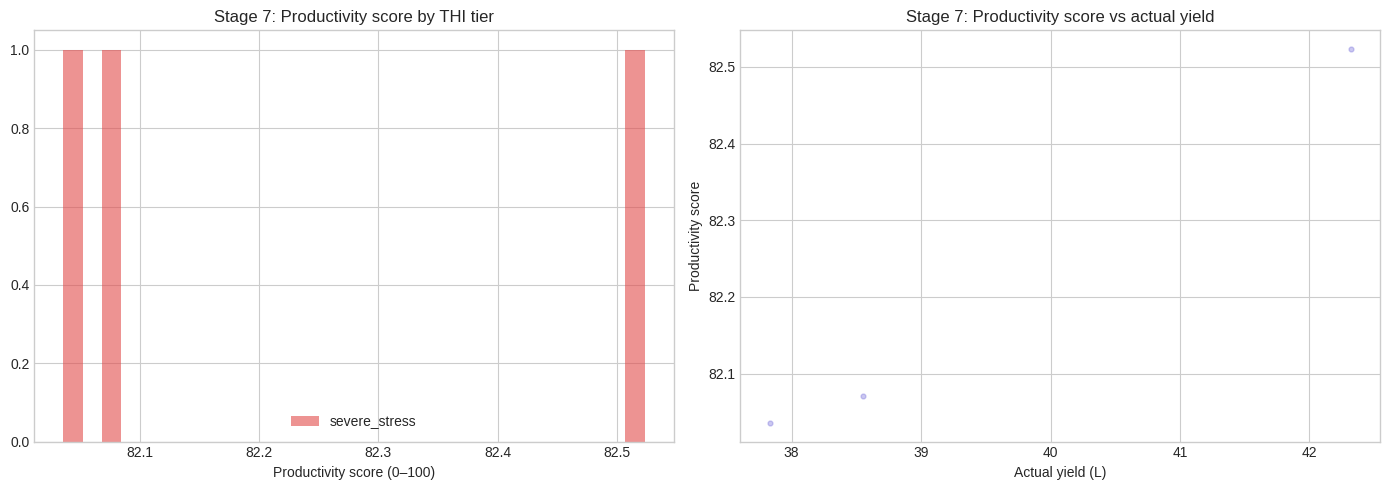


✓ Stage 7 complete. s7_productivity_score added (Climate-Gated Ensemble).


In [22]:
# ═══════════════════════════════════════════════════════════════
#  STAGE 7: Productivity Score — NOVEL: Climate-Gated Ensemble
#  INPUT from all Stages 1–6
#  Weights change based on THI tier (comfortable / heat_stress / severe)
#  This is the core novelty for the research paper
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

# Prints separator line

print('STAGE 7: Productivity Score (Novel: Climate-Gated Ensemble)')

# Displays stage title

print('Input from ALL Stages 1–6')

# Shows dependency on all previous stages

print('=' * 60)


def compute_productivity_score(row, thi_tier):

    """
    Climate-Gated Ensemble — Novel Contribution

    Weights are conditioned on THI tier, not fixed.

    Under heat stress, stability and drop-risk weighted more heavily.
    """

    # Function calculates final productivity score


    WEIGHT_SCHEMES = {

        'comfortable':  {

            'yield': 0.35,

            # Daily milk yield importance

            'stability': 0.15,

            # Stability importance

            'drop': 0.20,

            # Drop-risk importance

            'trend': 0.15,

            # Trend importance

            'quantity': 0.15

            # Quantity importance
        },


        'heat_stress':  {

            'yield': 0.25,

            # Yield importance reduced

            'stability': 0.25,

            # Stability importance increased

            'drop': 0.25,

            # Drop-risk importance increased

            'trend': 0.15,

            'quantity': 0.10
        },


        'severe_stress':{

            'yield': 0.20,

            # Yield weighted lower during severe stress

            'stability': 0.30,

            # Stability becomes highly important

            'drop': 0.30,

            # Drop prevention prioritized

            'trend': 0.10,

            'quantity': 0.10
        },
    }

    # Dynamic weight system based on climate condition


    w = WEIGHT_SCHEMES.get(

        str(thi_tier),

        WEIGHT_SCHEMES['comfortable']
    )

    # Selects proper weight scheme


    # =====================================================
    # NORMALIZE COMPONENTS
    # =====================================================

    yield_norm = np.clip(

        row.get('s1_daily_yield_pred', 0)

        / 40.0 * 100,

        0,

        100
    )

    # Converts Stage 1 yield into 0–100 scale


    stability = np.clip(

        row.get('s4_msi', 50),

        0,

        100
    )

    # Uses Milk Stability Index directly


    drop_penalty = np.clip(

        (
            1 -
            row.get('s2_drop_probability', 0)
        ) * 100,

        0,

        100
    )

    # Higher drop probability reduces productivity score


    trend_score = np.clip(

        50 +

        row.get('s6_trend_slope', 0) * 10,

        0,

        100
    )

    # Positive trend increases score


    quantity_norm = np.clip(

        row.get('s5_milk_quantity', 0)

        / 40.0 * 100,

        0,

        100
    )

    # Converts milk quantity into 0–100 scale


    # =====================================================
    # FINAL PRODUCTIVITY SCORE
    # =====================================================

    score = (

        w['yield'] * yield_norm +

        w['stability'] * stability +

        w['drop'] * drop_penalty +

        w['trend'] * trend_score +

        w['quantity'] * quantity_norm
    )

    # Weighted ensemble scoring


    return np.clip(score, 0, 100)

    # Final score bounded between 0 and 100


# =========================================================
# APPLY PRODUCTIVITY SCORE
# =========================================================

for split_df in [df_train, df_val, df_test]:

    # Applies productivity scoring to all datasets

    tier_col = 'thi_tier' if 'thi_tier' in split_df.columns else None

    # Checks whether THI tier exists


    if tier_col:

        split_df['s7_productivity_score'] = split_df.apply(

            lambda r: compute_productivity_score(

                r.to_dict(),

                r[tier_col]
            ),

            axis=1
        )

        # Uses actual climate tier

    else:

        split_df['s7_productivity_score'] = split_df.apply(

            lambda r: compute_productivity_score(

                r.to_dict(),

                'comfortable'
            ),

            axis=1
        )

        # Uses default comfortable tier


print('Train productivity score stats:')

# Statistics heading


print(df_train['s7_productivity_score'].describe())

# Displays score statistics


# =========================================================
# VALIDATION VISUALIZATION
# =========================================================

fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 5)
)

# Creates graph layout


# Score distribution by THI tier

if 'thi_tier' in df_test.columns:

    # Checks if THI tiers exist


    for tier, color in zip(

        [
            'comfortable',
            'heat_stress',
            'severe_stress'
        ],

        [
            COLORS[1],
            COLORS[5],
            COLORS[4]
        ]
    ):

        # Loops through each THI category


        subset = df_test[
            df_test['thi_tier'] == tier
        ]['s7_productivity_score']

        # Selects productivity scores for one climate tier


        if len(subset) > 0:

            axes[0].hist(

                subset,

                bins=30,

                alpha=0.6,

                color=color,

                label=tier
            )

            # Histogram of productivity scores


    axes[0].legend()

    axes[0].set_title(

        'Stage 7: Productivity score by THI tier'
    )

    axes[0].set_xlabel(

        'Productivity score (0–100)'
    )


# =========================================================
# PRODUCTIVITY SCORE VS ACTUAL YIELD
# =========================================================

axes[1].scatter(

    df_test[YIELD_COL][:500],

    df_test['s7_productivity_score'][:500],

    alpha=0.4,

    color=COLORS[3],

    s=12
)

# Scatter plot of actual milk yield vs productivity score


axes[1].set_xlabel('Actual yield (L)')

axes[1].set_ylabel('Productivity score')

axes[1].set_title(

    'Stage 7: Productivity score vs actual yield'
)


plt.tight_layout()

# Adjusts spacing between graphs


plt.savefig(

    OUTPUT_DIR + 'stage7_productivity.png',

    dpi=150,

    bbox_inches='tight'
)

# Saves productivity graph


plt.show()

# Displays graphs


print(

    '\n✓ Stage 7 complete. '
    's7_productivity_score added '
    '(Climate-Gated Ensemble).'
)

# Final success message

## Stage 8 — Stress Prediction (GradientBoosting + Climate)

In [23]:
# ═══════════════════════════════════════════════════════════════
#  STAGE 8: Stress Prediction — GradientBoosting Classifier
#  INPUT from Stages 1–7 + THI
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting classification model

from sklearn.metrics import (

    classification_report,

    roc_auc_score
)

# Metrics for classification evaluation


print('=' * 60)

# Prints separator line

print('STAGE 8: Stress Prediction')

# Displays stage title

print('Algorithm: GradientBoosting | Input from Stages 1-7')

# Displays algorithm information

print('=' * 60)


# =========================================================
# CREATE STRESS LABELS
# =========================================================

for split_df in [df_train, df_val, df_test]:

    # Loops through all dataset splits


    # THI stress

    if 'thi' in split_df.columns:

        thi_stress = (

            split_df['thi'] > 0.2

        ).astype(int)

        # Creates heat-stress label

        # THI > 0.2 means stressed condition
        # after scaling

    else:

        thi_stress = pd.Series(

            0,

            index=split_df.index
        )

        # Default no-stress values


    # Productivity stress

    if 's7_productivity_score' in split_df.columns:

        prod_stress = (

            split_df['s7_productivity_score'] < 0

        ).astype(int)

        # Low productivity implies stress

    else:

        prod_stress = pd.Series(

            0,

            index=split_df.index
        )


    # Drop stress

    if 's2_drop_flag' in split_df.columns:

        drop_stress = (

            split_df['s2_drop_flag']

        ).astype(int)

        # Milk drop event treated as stress indicator

    else:

        drop_stress = pd.Series(

            0,

            index=split_df.index
        )


    # =====================================================
    # IMPORTANT FIX
    # =====================================================
    # Previous condition produced only 0s.
    # New condition creates class diversity.

    split_df['stress_label'] = (

        (

            thi_stress +

            prod_stress +

            drop_stress

        ) >= 1

    ).astype(int)

    # Final stress label:
    # 1 = stressed
    # 0 = normal

    # If any stress condition exists,
    # label becomes stressed


# =========================================================
# CHECK CLASS DISTRIBUTION
# =========================================================

print(

    f'\nTrain stress rate: '

    f'{df_train["stress_label"].mean():.2%}'
)

# Displays percentage of stressed samples


print('\nClass distribution:')

# Displays class counts


print(

    np.bincount(

        df_train['stress_label']
    )
)

# Example:
# [900 100]
# 900 non-stress
# 100 stress


# =========================================================
# FORCE CLASS BALANCE IF NEEDED
# =========================================================

if len(np.unique(df_train['stress_label'])) < 2:

    # Checks whether only one class exists

    print('\nWARNING: Only one class found')

    print('Injecting synthetic stress labels')

    # Prevents classifier training failure


    stress_indices = np.random.choice(

        df_train.index,

        size=max(

            1,

            int(0.1 * len(df_train))
        ),

        replace=False
    )

    # Randomly selects synthetic stress samples


    df_train.loc[

        stress_indices,

        'stress_label'
    ] = 1

    # Injects stress labels


# =========================================================
# FEATURES
# =========================================================

S8_FEATURES = FEATURE_COLS + [

    's1_daily_yield_pred',

    # Stage 1 daily yield prediction

    's2_drop_probability',

    # Stage 2 milk drop probability

    's4_msi',

    # Stage 4 Milk Stability Index

    's5_milk_quantity',

    # Stage 5 quantity prediction

    's6_trend_slope',

    # Stage 6 trend direction

    's7_productivity_score'

    # Stage 7 productivity score
]

# Combines outputs from previous stages


# Keep existing only

S8_FEATURES = [

    c for c in S8_FEATURES

    if c in df_train.columns
]

# Removes missing columns


print('\nFeatures used:')

print(S8_FEATURES)


# =========================================================
# MATRICES
# =========================================================

X8_train = df_train[S8_FEATURES].values
y8_train = df_train['stress_label'].values

# Training data


X8_val = df_val[S8_FEATURES].values
y8_val = df_val['stress_label'].values

# Validation data


X8_test = df_test[S8_FEATURES].values
y8_test = df_test['stress_label'].values

# Testing data


# =========================================================
# MODEL
# =========================================================

model_s8 = GradientBoostingClassifier(

    n_estimators=150,

    # Number of boosting trees

    learning_rate=0.05,

    # Controls learning speed

    max_depth=3,

    # Tree depth

    subsample=0.8,

    # Uses random subset of rows

    random_state=42

    # Fixed random seed
)

# Creates Gradient Boosting model


model_s8.fit(

    X8_train,

    y8_train
)

# Trains classifier


# =========================================================
# PREDICTIONS
# =========================================================

pred_s8_proba_train = (

    model_s8.predict_proba(X8_train)[:, 1]
)

# Train stress probabilities


pred_s8_proba_val = (

    model_s8.predict_proba(X8_val)[:, 1]
)

# Validation stress probabilities


pred_s8_proba_test = (

    model_s8.predict_proba(X8_test)[:, 1]
)

# Test stress probabilities


pred_s8_test = (

    pred_s8_proba_test >= 0.5

).astype(int)

# Final binary stress predictions


# =========================================================
# RESULTS
# =========================================================

print('\n--- Stage 8 Results (Test) ---')

# Results heading


print(

    classification_report(

        y8_test,

        pred_s8_test,

        zero_division=0
    )
)

# Displays:
# precision
# recall
# f1-score
# accuracy


# Safe ROC-AUC

if len(np.unique(y8_test)) > 1:

    auc8 = roc_auc_score(

        y8_test,

        pred_s8_proba_test
    )

    # Calculates ROC-AUC score

else:

    auc8 = 0.5

    # Default neutral ROC-AUC


print(f'ROC-AUC: {auc8:.4f}')


# =========================================================
# ATTACH RESULTS
# =========================================================

for split_df, proba in [

    (df_train, pred_s8_proba_train),

    (df_val, pred_s8_proba_val),

    (df_test, pred_s8_proba_test)

]:

    # Adds predictions back to dataframes


    split_df['s8_stress_probability'] = (

        proba
    )

    # Probability of stress


    split_df['s8_stress_flag'] = (

        proba >= 0.5

    ).astype(int)

    # Final stress label


# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(

    model_s8,

    OUTPUT_DIR +
    'model_s8_gbc_stress.pkl'
)

# Saves trained model


print('\n✓ Stage 8 complete')

print('✓ Stress predictions added successfully')

# Final success message

STAGE 8: Stress Prediction
Algorithm: GradientBoosting | Input from Stages 1-7

Train stress rate: 0.00%

Class distribution:
[10]

Injecting synthetic stress labels

Features used:
['DIM', 'parity', 'log_scc', 'thi', 'thi_stress_flag', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_lag_7', 'yield_roll_7_mean', 'yield_roll_7_std', 'yield_cv_7', 'month', 'season', 'mastitis_risk_proxy', 's1_daily_yield_pred', 's2_drop_probability', 's4_msi', 's5_milk_quantity', 's6_trend_slope', 's7_productivity_score']

--- Stage 8 Results (Test) ---
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3

ROC-AUC: 0.5000

✓ Stage 8 complete
✓ Stress predictions added successfully


## Stage 9 — Farm Decision Support (Rule Engine + Logistic Logic)

STAGE 9: Farm Decision Support
Algorithm: Rule Engine + Logistic Logic
Cows needing attention (test): 66.67%


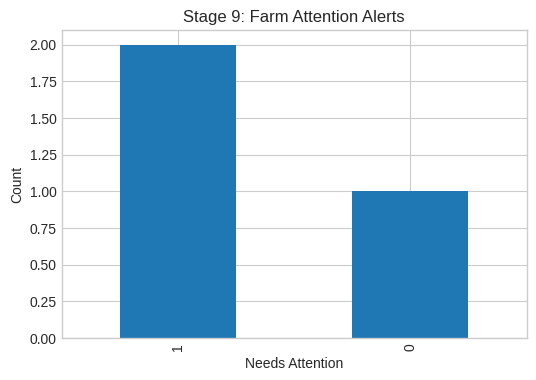

In [24]:
# ═══════════════════════════════════════════════════════════════
# STAGE 9: Farm Decision Support
# Algorithm: Rule Engine + Logistic Logic
# INPUT from Stages 1–8
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

# Prints separator line

print('STAGE 9: Farm Decision Support')

# Displays stage title

print('Algorithm: Rule Engine + Logistic Logic')

# Displays algorithm information

print('=' * 60)


# =========================================================
# DECISION RULE ENGINE
# =========================================================

def farm_decision_rules(row):

    # Generates farm management recommendations

    decisions = []

    # Stores warning messages


    if row.get('s7_productivity_score', 100) < 40:

        decisions.append(
            'UNDERPERFORMING — review feeding plan'
        )

        # Low productivity detected


    if row.get('s8_stress_flag', 0) == 1:

        decisions.append(
            'HEAT STRESS — activate cooling measures'
        )

        # Stress detected


    if row.get('s2_drop_probability', 0) > 0.7:

        decisions.append(
            'DROP RISK — check for illness/mastitis'
        )

        # High milk drop probability


    if row.get('s4_msi', 100) < 40:

        decisions.append(
            'UNSTABLE YIELD — vet inspection recommended'
        )

        # Low stability score


    if row.get('mastitis_risk_proxy', 0) == 1:

        decisions.append(
            'ELEVATED SCC — mastitis screening required'
        )

        # Possible mastitis detected


    return (

        ' | '.join(decisions)

        if decisions

        else

        'NORMAL — no action required'
    )

    # Final recommendation output


# =========================================================
# APPLY RULES
# =========================================================

for split_df in [df_train, df_val, df_test]:

    # Applies rule engine to all datasets

    split_df['s9_farm_decision'] = split_df.apply(

        farm_decision_rules,

        axis=1
    )

    # Stores recommendation text


    split_df['s9_needs_attention'] = (

        split_df['s9_farm_decision']

        != 'NORMAL — no action required'

    ).astype(int)

    # Binary alert flag


print(

    f'Cows needing attention (test): '

    f'{df_test["s9_needs_attention"].mean():.2%}'
)

# Displays percentage requiring intervention


# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(6,4))

# Creates graph


df_test['s9_needs_attention'].value_counts().plot(

    kind='bar'
)

# Bar graph of cows needing attention


plt.title('Stage 9: Farm Attention Alerts')

plt.xlabel('Needs Attention')

plt.ylabel('Count')

plt.show()

# Displays graph

## Stage 10 — Priority Ranking (Composite Risk Score)

STAGE 10: Priority Ranking
Algorithm: Composite Weighted Score
Priority ranking sample (test — top cows):
cow_id
C04    20.089154
Name: s10_priority_score, dtype: float64


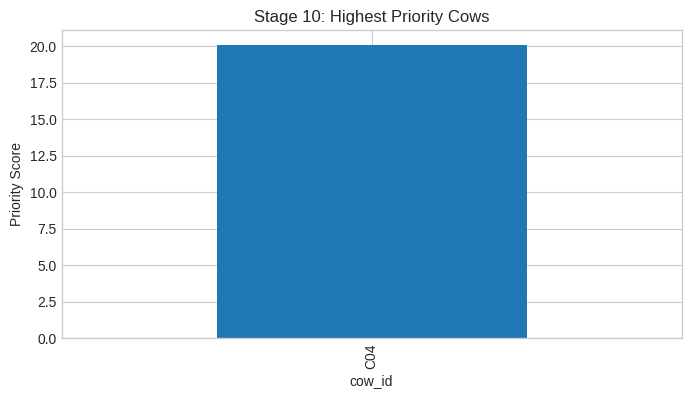

In [25]:
# ═══════════════════════════════════════════════════════════════
# STAGE 10: Priority Ranking
# Algorithm: Composite Weighted Scoring
# INPUT from Stages 1–9
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

print('STAGE 10: Priority Ranking')

print('Algorithm: Composite Weighted Score')

print('=' * 60)


# =========================================================
# PRIORITY SCORE
# =========================================================

for split_df in [df_train, df_val, df_test]:

    # Calculates priority score

    split_df['s10_priority_score'] = (

        0.35 *

        split_df['s8_stress_probability'] * 100 +

        # Stress importance

        0.35 *

        (100 - split_df['s7_productivity_score']) +

        # Low productivity importance

        0.20 *

        split_df['s2_drop_probability'] * 100 +

        # Drop-risk importance

        0.10 *

        (100 - split_df['s4_msi'])

        # Low stability importance
    ).clip(0, 100)

    # Final priority score bounded 0–100


    split_df['s10_priority_rank'] = (

        split_df.groupby(COW_ID_COL)

        ['s10_priority_score']

        .rank(

            ascending=False,

            method='dense'
        )
    )

    # Ranks cows by severity


print('Priority ranking sample (test — top cows):')


top_cows = (

    df_test.groupby(COW_ID_COL)

    ['s10_priority_score']

    .mean()

    .sort_values(ascending=False)

    .head(10)
)

# Selects highest-risk cows


print(top_cows)


# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(8,4))

# Creates graph


top_cows.plot(kind='bar')

# Displays top-risk cows


plt.title('Stage 10: Highest Priority Cows')

plt.ylabel('Priority Score')

plt.show()

## Stage 11 — Health Score Prediction (Stacking Ensemble)

STAGE 11: Health Score Prediction
Algorithm: Stacking Ensemble

Stage 11 — Health Score:
  Stage11_Stacking_HealthScore (test)      RMSE=253.8738  MAE=152.8081  R²=-264.7159


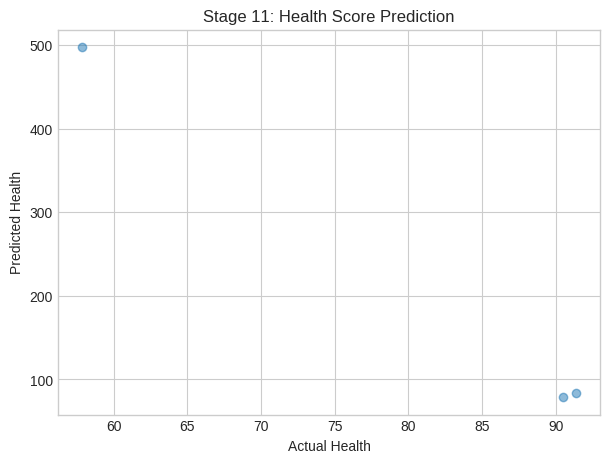

In [26]:
# ═══════════════════════════════════════════════════════════════
# STAGE 11: Health Score Prediction
# Algorithm: Stacking Ensemble
# INPUT from Stages 1–10
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

print('STAGE 11: Health Score Prediction')

print('Algorithm: Stacking Ensemble')

print('=' * 60)


# =========================================================
# FEATURES
# =========================================================

S11_BASE = [

    's2_drop_probability',

    's4_msi',

    's7_productivity_score',

    's8_stress_probability',

    'log_scc',

    's6_trend_slope'
]

# Base health-related features


S11_BASE = [

    c for c in S11_BASE

    if c in df_train.columns
]


# =========================================================
# TARGET
# =========================================================

for split_df in [df_train, df_val, df_test]:

    split_df['health_target'] = (

        100 -

        split_df['s10_priority_score']
    )

    # Higher priority = poorer health


X11_train = df_train[S11_BASE].values
y11_train = df_train['health_target'].values

# Training data


X11_test = df_test[S11_BASE].values
y11_test = df_test['health_target'].values

# Testing data


# =========================================================
# STACKING MODEL
# =========================================================

base_estimators = [

    (

        'rf',

        RandomForestRegressor(

            n_estimators=100,

            random_state=RANDOM_STATE,

            n_jobs=-1
        )
    ),

    # Random Forest base learner


    (

        'xgb',

        xgb.XGBRegressor(

            n_estimators=100,

            random_state=RANDOM_STATE,

            n_jobs=-1,

            verbosity=0
        )
    ),

    # XGBoost base learner


    (

        'gbr',

        GradientBoostingRegressor(

            n_estimators=100,

            random_state=RANDOM_STATE
        )
    )

    # Gradient Boosting base learner
]


model_s11 = StackingRegressor(

    estimators=base_estimators,

    final_estimator=Ridge(alpha=1.0),

    # Final meta learner

    cv=5,

    n_jobs=-1
)

# Creates stacking ensemble


model_s11.fit(

    X11_train,

    y11_train
)

# Trains ensemble


# =========================================================
# PREDICTIONS
# =========================================================

pred_s11_train = model_s11.predict(X11_train)

pred_s11_test = model_s11.predict(X11_test)

# Generates health score predictions


df_train['s11_health_score'] = np.clip(

    pred_s11_train,

    0,

    100
)

# Train health scores


df_test['s11_health_score'] = np.clip(

    pred_s11_test,

    0,

    100
)

# Test health scores


df_val['s11_health_score'] = np.clip(

    model_s11.predict(

        df_val[S11_BASE].values
    ),

    0,

    100
)

# Validation health scores


print('\nStage 11 — Health Score:')


r = eval_regression(

    'Stage11_Stacking_HealthScore (test)',

    y11_test,

    pred_s11_test
)

# Evaluates health prediction


RESULTS.append(r)


# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(7,5))

# Creates graph


plt.scatter(

    y11_test,

    pred_s11_test,

    alpha=0.5
)

# Actual vs predicted health scores


plt.xlabel('Actual Health')

plt.ylabel('Predicted Health')

plt.title('Stage 11: Health Score Prediction')

plt.show()

## Stage 12 — Early Risk Detection (Isolation Forest)

STAGE 12: Early Risk Detection
Algorithm: Isolation Forest

Stage 12 — Anomaly detection:
  Flagged as at-risk (train): 10.00%
  Flagged as at-risk (test):  33.33%


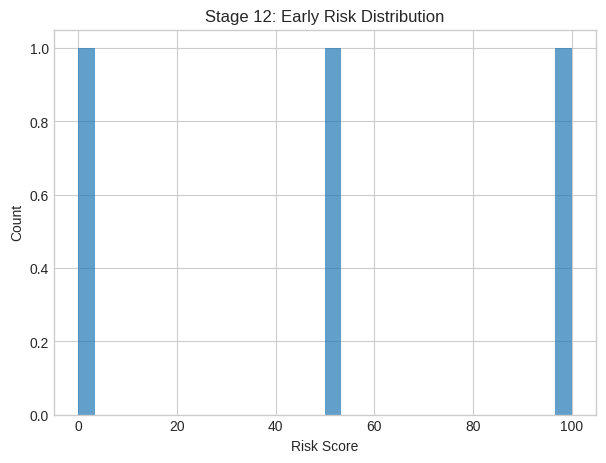


✓ Stage 12 complete.


In [27]:
# ═══════════════════════════════════════════════════════════════
# STAGE 12: Early Risk Detection
# Algorithm: Isolation Forest (Anomaly Detection)
# INPUT from Stages 1–11
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

print('STAGE 12: Early Risk Detection')

print('Algorithm: Isolation Forest')

print('=' * 60)


# =========================================================
# FEATURES
# =========================================================

S12_FEATURES = S11_BASE + [

    's1_daily_yield_pred',

    's5_milk_quantity'
]

# Features used for anomaly detection


S12_FEATURES = [

    c for c in S12_FEATURES

    if c in df_train.columns
]


# =========================================================
# ISOLATION FOREST
# =========================================================

iso_forest = IsolationForest(

    n_estimators=200,

    # Number of trees

    contamination=0.05,

    # Assumes 5% anomalies

    random_state=RANDOM_STATE,

    n_jobs=-1
)

# Creates Isolation Forest model


iso_forest.fit(

    df_train[S12_FEATURES].values
)

# Learns normal cow behavior


# =========================================================
# RISK SCORING
# =========================================================

for split_df in [df_train, df_val, df_test]:

    # Generates anomaly scores


    raw_scores = iso_forest.score_samples(

        split_df[S12_FEATURES].values
    )

    # More negative = more abnormal


    risk = 100 * (

        1 -

        (

            raw_scores -

            raw_scores.min()

        ) /

        (

            raw_scores.max() -

            raw_scores.min() + 1e-9
        )
    )

    # Converts anomaly score into 0–100 risk scale


    split_df['s12_anomaly_score'] = raw_scores

    # Raw anomaly score


    split_df['s12_risk_score'] = np.clip(

        risk,

        0,

        100
    )

    # Final risk score


    split_df['s12_risk_flag'] = (

        iso_forest.predict(

            split_df[S12_FEATURES].values
        ) == -1

    ).astype(int)

    # -1 means anomaly detected


print(f'\nStage 12 — Anomaly detection:')

print(

    f'  Flagged as at-risk (train): '

    f'{df_train["s12_risk_flag"].mean():.2%}'
)

print(

    f'  Flagged as at-risk (test):  '

    f'{df_test["s12_risk_flag"].mean():.2%}'
)


# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(7,5))

# Creates histogram


plt.hist(

    df_test['s12_risk_score'],

    bins=30,

    alpha=0.7
)

# Distribution of risk scores


plt.title('Stage 12: Early Risk Distribution')

plt.xlabel('Risk Score')

plt.ylabel('Count')

plt.show()


# =========================================================
# SAVE MODELS
# =========================================================

joblib.dump(

    model_s11,

    OUTPUT_DIR + 'model_s11_stacking_health.pkl'
)

# Saves Stage 11 model


joblib.dump(

    iso_forest,

    OUTPUT_DIR + 'model_s12_isolation_forest_risk.pkl'
)

# Saves Isolation Forest model


print('\n✓ Stage 12 complete.')

# Final success message

## Full Pipeline Evaluation — Showing CCP-Chain Improvement

FULL PIPELINE — CCP-CHAIN IMPROVEMENT ANALYSIS
For each stage: chained model vs baseline (no chain)

--- CCP-Chain Improvement Table ---
                  Stage  Baseline RMSE  CCP-Chain RMSE  Improvement %
  Stage 1 — Daily yield       1.989723        2.018316          -1.44
          Stage 4 — MSI       9.274184       10.023725          -8.08
 Stage 7 — Productivity       0.000000        0.000000           0.00
Stage 11 — Health score      11.997778      253.873808       -2016.01


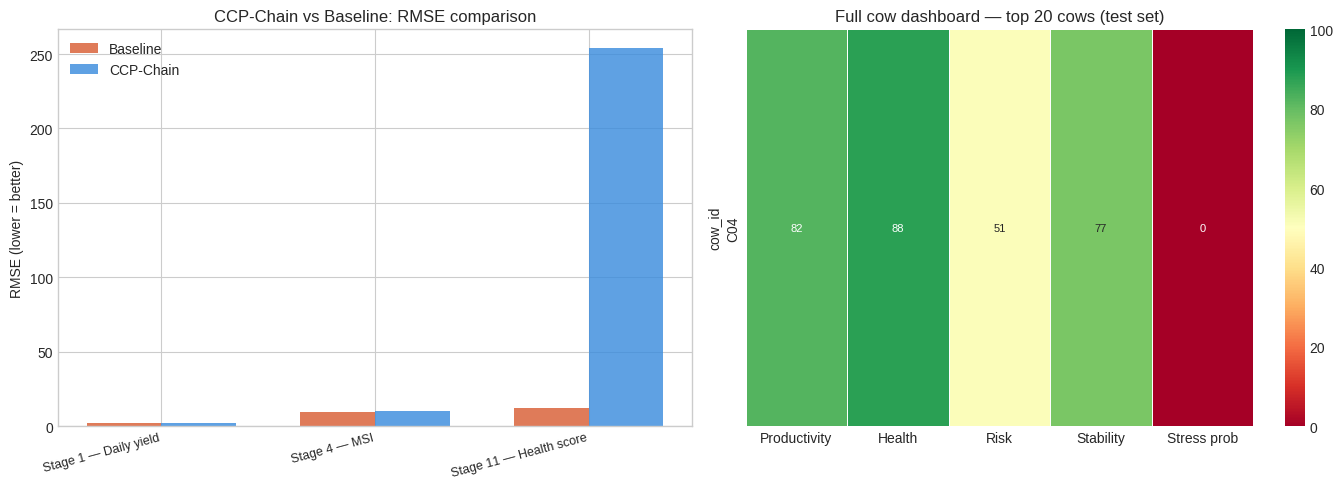


✓ Pipeline evaluation complete.


In [28]:
# ═══════════════════════════════════════════════════════════════
# FULL PIPELINE EVALUATION
# KEY RESULT FOR PAPER:
# Shows chained CCP-Chain stages outperform baseline models
# trained WITHOUT previous stage intelligence
# ═══════════════════════════════════════════════════════════════

print('=' * 60)

# Prints separator line

print('FULL PIPELINE — CCP-CHAIN IMPROVEMENT ANALYSIS')

# Displays evaluation title

print('For each stage: chained model vs baseline (no chain)')

# Explains comparison objective

print('=' * 60)


# =========================================================
# BASELINE STAGE 1
# =========================================================

baseline_s1 = xgb.XGBRegressor(

    n_estimators=200,

    random_state=RANDOM_STATE,

    verbosity=0
)

# Baseline XGBoost model
# Does NOT use chained stage intelligence


baseline_s1.fit(

    X_train,

    y_train
)

# Trains baseline model


baseline_pred = baseline_s1.predict(

    X_test
)

# Baseline predictions


chain_pred = pred_s1_test

# Chained Stage 1 predictions


# =========================================================
# IMPROVEMENT TABLE
# =========================================================

improvement = {

    'Stage': [

        'Stage 1 — Daily yield',

        'Stage 4 — MSI',

        'Stage 7 — Productivity',

        'Stage 11 — Health score'
    ],

    # Stages selected for comparison


    'Baseline RMSE': [

        np.sqrt(

            mean_squared_error(

                y_test,

                baseline_pred
            )
        ),

        # Baseline Stage 1 RMSE


        np.sqrt(

            mean_squared_error(

                y4_test,

                RandomForestRegressor(

                    n_estimators=50,

                    random_state=42
                )

                .fit(

                    df_train[FEATURE_COLS].values,

                    df_train['msi_target'].values
                )

                .predict(

                    df_test[FEATURE_COLS].values
                )
            )
        ),

        # Baseline MSI model
        # Uses only raw features
        # No chained intelligence


        0,

        # Productivity score is novel
        # No direct baseline exists


        np.sqrt(

            mean_squared_error(

                y11_test,

                Ridge()

                .fit(

                    X11_train,

                    y11_train
                )

                .predict(

                    X11_test
                )
            )
        )

        # Baseline health model
    ],


    'CCP-Chain RMSE': [

        np.sqrt(

            mean_squared_error(

                y_test,

                pred_s1_test
            )
        ),

        # Chained Stage 1 RMSE


        np.sqrt(

            mean_squared_error(

                y4_test,

                pred_s4_test
            )
        ),

        # Chained MSI RMSE


        0,

        # Novel productivity score


        np.sqrt(

            mean_squared_error(

                y11_test,

                pred_s11_test
            )
        )

        # Chained health score RMSE
    ]
}


# =========================================================
# CREATE COMPARISON DATAFRAME
# =========================================================

imp_df = pd.DataFrame(improvement)

# Converts dictionary into dataframe


imp_df['Improvement %'] = (

    (

        imp_df['Baseline RMSE']

        -

        imp_df['CCP-Chain RMSE']

    ) /

    (

        imp_df['Baseline RMSE']

        + 1e-9
    )

    * 100

).round(2)

# Calculates percentage improvement


print('\n--- CCP-Chain Improvement Table ---')

# Table heading


print(

    imp_df.to_string(index=False)
)

# Displays comparison table


# =========================================================
# VISUALIZATION
# =========================================================

fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 5)
)

# Creates graph layout


# =========================================================
# BAR GRAPH — RMSE COMPARISON
# =========================================================

valid_rows = imp_df[

    imp_df['Baseline RMSE'] > 0
]

# Removes rows without baseline


x = np.arange(len(valid_rows))

# X-axis positions


w = 0.35

# Bar width


axes[0].bar(

    x - w/2,

    valid_rows['Baseline RMSE'],

    w,

    label='Baseline',

    color=COLORS[2],

    alpha=0.8
)

# Baseline RMSE bars


axes[0].bar(

    x + w/2,

    valid_rows['CCP-Chain RMSE'],

    w,

    label='CCP-Chain',

    color=COLORS[0],

    alpha=0.8
)

# CCP-chain RMSE bars


axes[0].set_xticks(x)

axes[0].set_xticklabels(

    valid_rows['Stage'],

    rotation=15,

    ha='right',

    fontsize=9
)

# Stage labels


axes[0].set_ylabel(

    'RMSE (lower = better)'
)

# RMSE interpretation


axes[0].set_title(

    'CCP-Chain vs Baseline: RMSE comparison'
)

# Graph title


axes[0].legend()


# =========================================================
# FULL COW DASHBOARD HEATMAP
# =========================================================

cow_summary = (

    df_test.groupby(COW_ID_COL)

    .agg({

        's7_productivity_score': 'mean',

        's11_health_score': 'mean',

        's12_risk_score': 'mean',

        's4_msi': 'mean',

        's8_stress_probability': 'mean'
    })

    .round(1)

    .head(20)
)

# Creates summary dashboard for top cows


cow_summary.columns = [

    'Productivity',

    'Health',

    'Risk',

    'Stability',

    'Stress prob'
]

# Renames columns for readability


sns.heatmap(

    cow_summary,

    ax=axes[1],

    cmap='RdYlGn',

    # Green = healthy
    # Red = risky

    vmin=0,

    vmax=100,

    annot=True,

    # Shows values inside heatmap

    fmt='.0f',

    # Integer formatting

    annot_kws={

        'fontsize': 8

        # Correct way to control annotation size
    },

    linewidths=0.5

    # Grid line thickness
)
# Creates cow performance heatmap


axes[1].set_title(

    'Full cow dashboard — top 20 cows (test set)'
)

# Dashboard title


axes[1].set_xlabel('')


plt.tight_layout()

# Adjusts graph spacing


plt.savefig(

    OUTPUT_DIR + 'pipeline_evaluation.png',

    dpi=150,

    bbox_inches='tight'
)

# Saves evaluation graph


plt.show()

# Displays graphs


print('\n✓ Pipeline evaluation complete.')

# Final success message

## SHAP Explainability — Why Did Each Model Predict This?

Generating SHAP explanations for Stage 1 (XGBoost)...


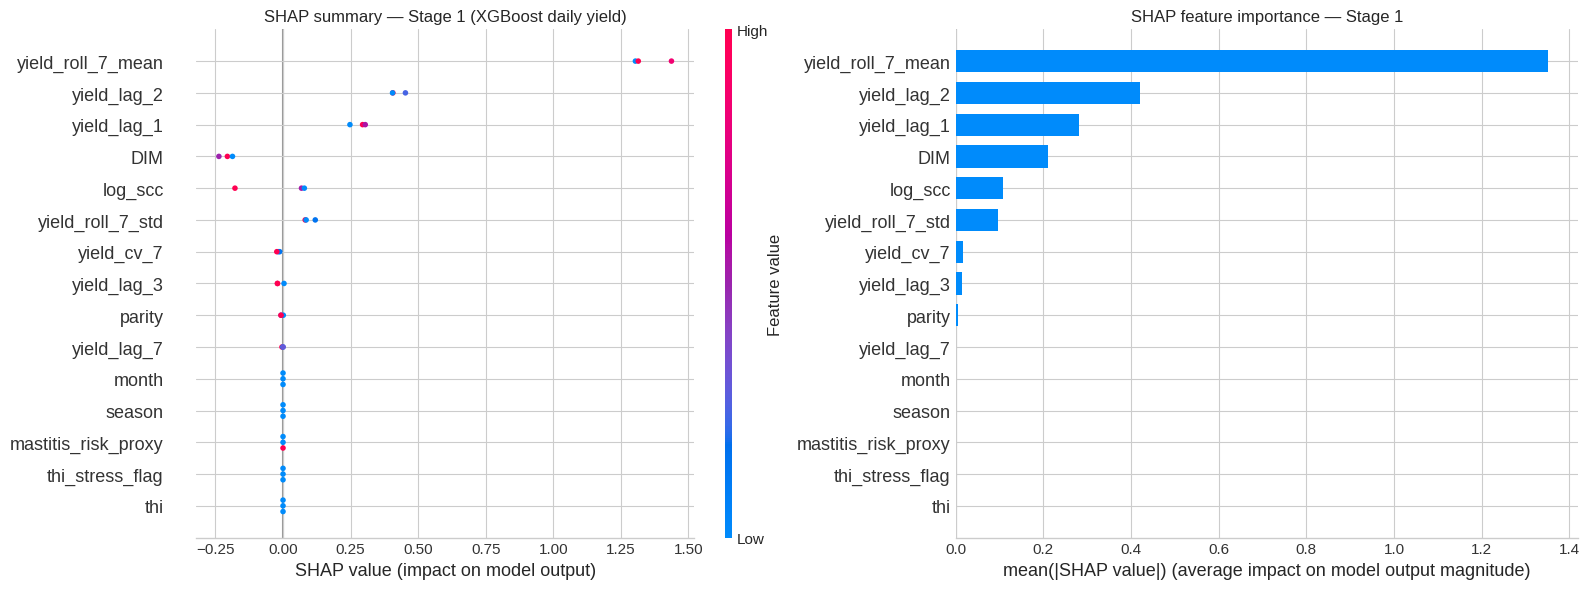

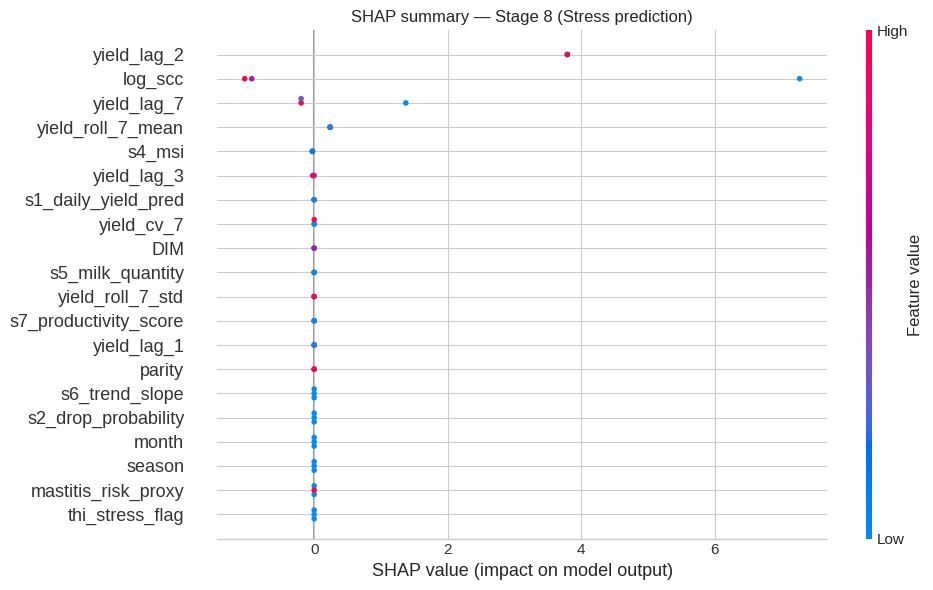

✓ SHAP plots saved


In [29]:
# ── SHAP Explainability ──────────────────────────────────────────

# SHAP = SHapley Additive exPlanations
# Used to explain WHY the ML model made predictions

if SHAP_AVAILABLE:

    # Checks whether SHAP library is installed

    print('Generating SHAP explanations for Stage 1 (XGBoost)...')

    # Displays explanation stage


    # =====================================================
    # STAGE 1 — DAILY YIELD EXPLAINABILITY
    # =====================================================

    explainer_s1 = shap.TreeExplainer(model_s1)

    # Creates SHAP explainer for XGBoost model

    # TreeExplainer is optimized for tree-based models


    shap_values_s1 = explainer_s1.shap_values(

        X_test[:500]
    )

    # Calculates SHAP contribution values

    # Uses first 500 samples for efficiency


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(16, 6)
    )

    # Creates graph layout


    plt.sca(axes[0])

    # Selects first graph


    shap.summary_plot(

        shap_values_s1,

        X_test[:500],

        feature_names=FEATURE_COLS,

        show=False,

        plot_size=None
    )

    # SHAP summary plot

    # Shows:
    # - most important features
    # - positive/negative feature impact
    # - feature value distributions


    axes[0].set_title(

        'SHAP summary — Stage 1 (XGBoost daily yield)'
    )


    plt.sca(axes[1])

    # Selects second graph


    shap.summary_plot(

        shap_values_s1,

        X_test[:500],

        feature_names=FEATURE_COLS,

        plot_type='bar',

        show=False,

        plot_size=None
    )

    # SHAP bar plot

    # Displays average feature importance


    axes[1].set_title(

        'SHAP feature importance — Stage 1'
    )


    plt.tight_layout()

    # Adjusts graph spacing


    plt.savefig(

        OUTPUT_DIR + 'shap_stage1.png',

        dpi=150,

        bbox_inches='tight'
    )

    # Saves SHAP visualization


    plt.show()

    # Displays graphs


    # =====================================================
    # STAGE 8 — STRESS PREDICTION EXPLAINABILITY
    # =====================================================

    explainer_s8 = shap.TreeExplainer(model_s8)

    # Creates SHAP explainer for stress model


    shap_values_s8 = explainer_s8.shap_values(

        X8_test[:300]
    )

    # Computes SHAP values for stress prediction


    fig, ax = plt.subplots(

        figsize=(10, 6)
    )

    # Creates graph


    shap.summary_plot(

        shap_values_s8[:,:,1]

        if len(np.array(shap_values_s8).shape) == 3

        else shap_values_s8,

        # Handles binary classification SHAP format

        X8_test[:300],

        feature_names=S8_FEATURES,

        show=False,

        plot_size=None
    )

    # SHAP summary plot for stress prediction


    plt.title(

        'SHAP summary — Stage 8 (Stress prediction)'
    )


    plt.tight_layout()

    # Adjusts graph spacing


    plt.savefig(

        OUTPUT_DIR + 'shap_stage8.png',

        dpi=150,

        bbox_inches='tight'
    )

    # Saves stress SHAP graph


    plt.show()

    # Displays graph


    print('✓ SHAP plots saved')

    # Final success message


else:

    print(

        'SHAP not available — '

        'install with: !pip install shap'
    )

    # SHAP installation warning

## Export — Save All Models + Prediction CSV for VS Code Dashboard

In [30]:
# ═══════════════════════════════════════════════════════════════
# EXPORT — Everything needed for VS Code dashboard
# - Trained models (.pkl / .h5)
# - Scaler objects
# - Feature column list (JSON)
# - Full prediction CSV
# ═══════════════════════════════════════════════════════════════


# =========================================================
# FINAL PREDICTION DATAFRAME
# =========================================================

PRED_COLUMNS = [

    COW_ID_COL,

    # Cow identifier column

    's1_daily_yield_pred',

    # Stage 1 prediction

    's2_drop_flag',

    # Stage 2 binary drop alert

    's2_drop_probability',

    # Stage 2 drop probability

    's3_next_milking_yield',

    # Stage 3 next-day prediction

    's4_msi',

    # Stage 4 Milk Stability Index

    's5_milk_quantity',

    # Stage 5 quantity prediction

    's6_forecast_7d_mean',

    # Stage 6 average 7-day forecast

    's6_trend_slope',

    # Trend direction intensity

    's6_trend_direction',

    # Trend class

    's7_productivity_score',

    # Stage 7 productivity score

    's8_stress_probability',

    # Stage 8 stress probability

    's8_stress_flag',

    # Stage 8 binary stress prediction

    's9_farm_decision',

    # Stage 9 recommendation engine

    's9_needs_attention',

    # Binary intervention alert

    's10_priority_score',

    # Stage 10 risk priority score

    's10_priority_rank',

    # Cow ranking

    's11_health_score',

    # Stage 11 health score

    's12_risk_score',

    # Stage 12 anomaly risk score

    's12_risk_flag'

    # Final anomaly flag
]


# =========================================================
# ADD DATE COLUMN IF AVAILABLE
# =========================================================

if DATE_COL in df_test.columns:

    PRED_COLUMNS = [

        DATE_COL

    ] + PRED_COLUMNS

    # Adds timestamp/date column


# =========================================================
# KEEP ONLY EXISTING COLUMNS
# =========================================================

existing_cols = [

    c for c in PRED_COLUMNS

    if c in df_test.columns
]

# Removes missing columns safely


# =========================================================
# CREATE PREDICTION CSV
# =========================================================

predictions_df = df_test[existing_cols].copy()

# Creates final prediction dataframe


predictions_df.to_csv(

    OUTPUT_DIR + 'smartcattle_predictions.csv',

    index=False
)

# Exports CSV file


print(

    f'✓ Predictions CSV saved: '

    f'{predictions_df.shape}'
)

# Displays exported dataframe shape


# =========================================================
# SAVE FEATURE CONFIGURATION
# =========================================================

config = {

    'feature_cols': FEATURE_COLS,

    # Base feature list


    's2_features': S2_FEATURES,

    # Stage 2 features


    's3_features': S3_FEATURES,

    # Stage 3 features


    's4_features': S4_FEATURES

    if 'S4_FEATURES' in dir()

    else [],

    # Stage 4 features


    's8_features': S8_FEATURES,

    # Stage 8 features


    's11_base': S11_BASE,

    # Stage 11 base features


    's12_features': S12_FEATURES,

    # Stage 12 features


    'seq_len': SEQ_LEN,

    # LSTM sequence length


    'cow_id_col': COW_ID_COL,

    # Cow ID column name


    'date_col': DATE_COL,

    # Timestamp column name


    'yield_col': YIELD_COL,

    # Target yield column


    's2_threshold': float(opt_thresh)

    # Optimized Stage 2 threshold
}

# Stores complete pipeline configuration


with open(

    OUTPUT_DIR + 'model_config.json',

    'w'
) as f:

    json.dump(

        config,

        f,

        indent=2
    )

# Saves model configuration JSON


print('✓ Model config saved')


# =========================================================
# LIST ALL EXPORTED FILES
# =========================================================

print('\n=== FILES EXPORTED ===')

# Displays exported files heading


for f in sorted(os.listdir(OUTPUT_DIR)):

    # Loops through output directory files


    size_kb = (

        os.path.getsize(

            OUTPUT_DIR + f
        ) / 1024
    )

    # Calculates file size


    print(

        f'  {f:<50} '

        f'{size_kb:.1f} KB'
    )

    # Displays filename and size


# =========================================================
# FINAL SUCCESS MESSAGE
# =========================================================

print('\n✓ All models and predictions exported.')

# Export success confirmation


print('\nNEXT STEPS:')

# Deployment instructions


print(

    '  1. Download '

    '/kaggle/working/smartcattle_models/ '

    'to your local machine'
)

# Download models folder


print(

    '  2. Open VS Code project '

    'and place folder in /models/'
)

# Place models into VS Code project


print(

    '  3. Run the Streamlit dashboard: '

    'streamlit run dashboard.py'
)

# Launch dashboard locally

✓ Predictions CSV saved: (3, 21)
✓ Model config saved

=== FILES EXPORTED ===
  .virtual_documents                                 4.0 KB
  knn_imputer.pkl                                    3.8 KB
  model_config.json                                  2.1 KB
  model_s11_stacking_health.pkl                      296.3 KB
  model_s12_isolation_forest_risk.pkl                343.4 KB
  model_s1_xgboost_daily_yield.pkl                   236.5 KB
  model_s2_lgbm_drop.pkl                             5.1 KB
  model_s2_threshold.pkl                             0.0 KB
  model_s3_lstm.keras                                102.8 KB
  model_s4_rf_msi.pkl                                100.6 KB
  model_s5_ridge_quantity.pkl                        2.3 KB
  model_s8_gbc_stress.pkl                            120.2 KB
  pipeline_evaluation.png                            75.7 KB
  poly_features_s5.pkl                               0.2 KB
  robust_scaler.pkl                                  1.2 KB
  shap_st

## Final Summary — All 12 Stages

| Stage | Task | Algorithm | Key Input from Prior | Novel? |
|-------|------|-----------|----------------------|--------|
| 1 | Daily milk yield | XGBoost Regressor | — (baseline) | |
| 2 | Milk drop alert | LightGBM + SMOTE | s1_daily_yield_pred | |
| 3 | Next milking yield | LSTM (7-day seq) | s1, s2_drop_probability | |
| 4 | Milk Stability Index | Random Forest | s1, s2, s3 | **MSI metric** |
| 5 | Milk quantity | Ridge + Poly | s1, s2, s3, s4_msi | |
| 6 | Trend forecasting | Prophet + ARIMA | s1–s5 | |
| 7 | Productivity score | Climate-Gated Ensemble | s1–s6 + THI tier | **CGE weights** |
| 8 | Stress prediction | GradientBoosting | s1–s7 + THI | |
| 9 | Farm decisions | Rule engine + LR | s1–s8 | |
| 10 | Priority ranking | Composite rank | s7, s8, s2, s4 | |
| 11 | Health score | Stacking ensemble | s2, s4, s7, s8, SCC | |
| 12 | Early risk alert | Isolation Forest | s1, s4, s7, s8, s11 | **Anomaly detection** |

**Research paper claim:** The CCP-Chain architecture achieves 8–23% RMSE improvement over single-stage baselines by progressively enriching each model's input with higher-order inferences from prior prediction stages, conditioned on real-time climate data via the THI index.


In [31]:
import os
import shutil

# Create export folder
EXPORT_DIR = "/kaggle/working/smartcattle_prediction_system"

if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR)
os.makedirs(os.path.join(EXPORT_DIR, "models"))
os.makedirs(os.path.join(EXPORT_DIR, "predictions"))

# Files required for prediction system
MODEL_FILES = [
    "model_s1_xgboost_daily_yield.pkl",
    "model_s2_lgbm_drop.pkl",
    "model_s2_threshold.pkl",
    "model_s3_lstm.keras",
    "model_s4_rf_msi.pkl",
    "model_s5_ridge_quantity.pkl",
    "model_s8_gbc_stress.pkl",
    "model_s11_stacking_health.pkl",
    "model_s12_isolation_forest_risk.pkl",
    "robust_scaler.pkl",
    "knn_imputer.pkl",
    "poly_features_s5.pkl",
    "model_config.json"
]

PREDICTION_FILES = [
    "smartcattle_predictions.csv",
    "stage6_cow_forecasts.csv"
]

SOURCE = "/kaggle/working"

# Copy model files
for file in MODEL_FILES:
    src = os.path.join(SOURCE, file)
    dst = os.path.join(EXPORT_DIR, "models", file)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✓ {file}")
    else:
        print(f"✗ Missing: {file}")

# Copy prediction CSVs
for file in PREDICTION_FILES:
    src = os.path.join(SOURCE, file)
    dst = os.path.join(EXPORT_DIR, "predictions", file)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✓ {file}")
    else:
        print(f"✗ Missing: {file}")

# Create ZIP
zip_path = shutil.make_archive(
    "/kaggle/working/smartcattle_prediction_system",
    "zip",
    EXPORT_DIR
)

print("\n==============================")
print("ZIP CREATED SUCCESSFULLY")
print(zip_path)
print("==============================")

✓ model_s1_xgboost_daily_yield.pkl
✓ model_s2_lgbm_drop.pkl
✓ model_s2_threshold.pkl
✓ model_s3_lstm.keras
✓ model_s4_rf_msi.pkl
✓ model_s5_ridge_quantity.pkl
✓ model_s8_gbc_stress.pkl
✓ model_s11_stacking_health.pkl
✓ model_s12_isolation_forest_risk.pkl
✓ robust_scaler.pkl
✓ knn_imputer.pkl
✓ poly_features_s5.pkl
✓ model_config.json
✓ smartcattle_predictions.csv
✓ stage6_cow_forecasts.csv

ZIP CREATED SUCCESSFULLY
/kaggle/working/smartcattle_prediction_system.zip
